In [109]:
from pathlib import Path

import numpy as np
import pandas as pd

import xarray as xr
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import cartopy.crs as ccrs
from matplotlib.patches import Polygon

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 18})

# About
__Date:__ 02/21/25  
__Author:__ Pat McCornack  
__Purpose:__ Extracts albedo and cloud fraction from given points in order to compare them and develop a cloud/no cloud threshold for cloud fraction. This is in support of comparing the GOES CLC data with WRF model outputs. 

# Functions

In [ ]:
def get_bounds(ds, site):
    target_lat = site['lat']
    target_lon = site['lon']
    
    # Find the nearest lat/lon index
    lat_idx = np.abs(ds['lat'] - target_lat).argmin().item()
    lon_idx = np.abs(ds['lon'] - target_lon).argmin().item()

    # Extract the 3×3 neighboring grid cells
    lat_slice = slice(lat_idx - 1, lat_idx + 2)
    lon_slice = slice(lon_idx - 1, lon_idx + 2)
    subset = ds.isel(lat=lat_slice, lon=lon_slice)

    lat_min, lat_max = subset['lat'].min(), subset['lat'].max()
    lon_min, lon_max = subset['lon'].min(), subset['lon'].max()

    # Make polygons encompass cells
    lat_spacing = np.abs(ds['lat'].diff(dim='lat')).mean().item()  # Degrees
    lon_spacing = np.abs(ds['lon'].diff(dim='lon')).mean().item()  # Degrees
    lat_min = lat_min - lat_spacing / 2
    lat_max = lat_max + lat_spacing / 2
    lon_min = lon_min - lon_spacing / 2
    lon_max = lon_max + lon_spacing / 2

    # Define polygon corners
    rect_corners = [
        (lon_min, lat_min),  # Bottom-left
        (lon_max, lat_min),  # Bottom-right
        (lon_max, lat_max),  # Top-right
        (lon_min, lat_max),  # Top-left
        (lon_min, lat_min)   # Closing the rectangle
    ]
    bounds_dict = {'site' : site['site'],
                    'lat_min' : [float(lat_min.values)],
                    'lat_max' : [float(lat_max.values)],
                    'lon_min' : [float(lon_min.values)],
                    'lon_max' : [float(lon_max.values)],
                    'bounds' : [rect_corners]}

    return pd.DataFrame(bounds_dict)

# Get frequencies for regions of interest
def get_roi_freq(ds, roi_df):
    freq_df = pd.DataFrame()
    for name in roi_df['name'].tolist():
        # Subset to specific region of interest
        site_coords = roi_df.loc[roi_df['name'] == name]
        roi_ds = ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))
        
        # Getting % of matching observations, aggregated by year
        total_count = roi_ds.count('time')
        roi_ds = roi_ds.sum('time')
        roi_ds = (roi_ds / total_count) * 100

        # Average over the ROI
        roi_ds_mean = roi_ds.mean()

        # Create site dataframe
        data_dict = {'site' : name, 
                    'goes_freq' : roi_ds_mean['alb_binary'].values,
                    'wrf_freq' : roi_ds_mean['wrf_binary'].values,
                    'match_freq' : roi_ds_mean['match'].values}
        site_freq_df = pd.DataFrame(data_dict, index=[0])

        # Join together with all sites
        freq_df = pd.concat([freq_df, site_freq_df])

    return freq_df

# Get dataframe of statistics
def get_freq(ds, roi_df):
    freq_df = pd.DataFrame()

    # Get overall frequencies
    ds_gp = ds.sum('time')
    total_count = ds.count('time')
    ds_gp = (ds_gp / total_count) * 100
    ds_gp = ds_gp.mean(dim=['lat', 'lon'])

    overall_dict = {
        'site' : 'overall',
        'goes_freq' : ds_gp['alb_binary'].values,
        'wrf_freq' : ds_gp['wrf_binary'].values,
        'match_freq' : ds_gp['match'].values
    }
    freq_df = pd.concat([freq_df, pd.DataFrame(overall_dict, index=[0])])

    # Get ROI frequencies
    for name in roi_df['name'].tolist():
        # Subset to specific region of interest
        site_coords = roi_df.loc[roi_df['name'] == name]
        roi_ds = ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))
        
        # Getting % of matching observations, aggregated by year
        total_count = roi_ds.count('time')
        roi_ds = roi_ds.sum('time')
        roi_ds = (roi_ds / total_count) * 100

        # Average over the ROI
        roi_ds_mean = roi_ds.mean()

        # Create site dataframe
        data_dict = {'site' : name, 
                    'goes_freq' : roi_ds_mean['alb_binary'].values,
                    'wrf_freq' : roi_ds_mean['wrf_binary'].values,
                    'match_freq' : roi_ds_mean['match'].values}

        # Join together with all sites
        freq_df = pd.concat([freq_df, pd.DataFrame(data_dict, index=[0])])
    return freq_df

# Get ROI mean monthly frequencies
def get_monthly_freq(ds, roi_df):
    freq_df = pd.DataFrame()
    for name in roi_df['name'].tolist():
        # Subset to specific region of interest
        site_coords = roi_df.loc[roi_df['name'] == name]
        roi_ds = ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))
        
        # Getting % of matching observations, aggregated by year
        months_ds = roi_ds.groupby('time.month').sum('time')
        months_count = roi_ds.groupby('time.month').count('time')
        months_ds = (months_ds / months_count) * 100
        months_ds

        for month in list(months_ds['month'].values):

            # Average over the ROI
            roi_ds_mean = months_ds.sel(month=month).mean()

            # Create site dataframe
            data_dict = {'site' : name,
                        'month' : month, 
                        'goes_freq' : roi_ds_mean['alb_binary'].values,
                        'wrf_freq' : roi_ds_mean['wrf_binary'].values,
                        'match_freq' : roi_ds_mean['match'].values}
            site_freq_df = pd.DataFrame(data_dict, index=[0])

            # Join together with all sites
            freq_df = pd.concat([freq_df, site_freq_df])

    return freq_df

# Get ROI mean frequencies by year
def get_yearly_freq(ds, roi_df):
    freq_df = pd.DataFrame()
    for name in roi_df['name'].tolist():
        # Subset to specific region of interest
        site_coords = roi_df.loc[roi_df['name'] == name]
        roi_ds = ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))
        
        # Getting % of matching observations, aggregated by year
        years_ds = roi_ds.groupby('time.year').sum('time')
        years_count = roi_ds.groupby('time.year').count('time')
        years_ds = (years_ds / years_count) * 100
        years_ds

        for year in list(years_ds['year'].values):

            # Average over the ROI
            roi_ds_mean = years_ds.sel(year=year).mean()

            # Create site dataframe
            data_dict = {'site' : name,
                        'year' : year, 
                        'goes_freq' : roi_ds_mean['alb_binary'].values,
                        'wrf_freq' : roi_ds_mean['wrf_binary'].values,
                        'match_freq' : roi_ds_mean['match'].values}
            site_freq_df = pd.DataFrame(data_dict, index=[0])

            # Join together with all sites
            freq_df = pd.concat([freq_df, site_freq_df])
    return freq_df


# Process Data

In [32]:
# Define filepaths
root_dir = Path().resolve().parents[0]
sample_points_fpath = root_dir / 'data' / 'geospatial' / 'clc-cldfrc-sample-points' / 'clc-cldfrc-sample-points.csv'
clc_fpath = root_dir / 'data' / 'geospatial' / 'clemesha-clc' / 'cldalb-sci.nc'
wrf_fpath = root_dir / 'data' / 'wrf-low-cloud' / 'wrf-low-cld-partial.nc'

# Read in data
clc_da = xr.open_dataarray(clc_fpath)
wrf_da = xr.open_dataarray(wrf_fpath)
sample_points = pd.read_csv(sample_points_fpath, usecols=['Station', 'Latitude', 'Longitude', 'type'])
sample_points.loc[sample_points['Station'].isna(), 'Station'] = [f"point_{i+1}" for i in range(sample_points['Station'].isna().sum())]
sample_points = sample_points.dropna()


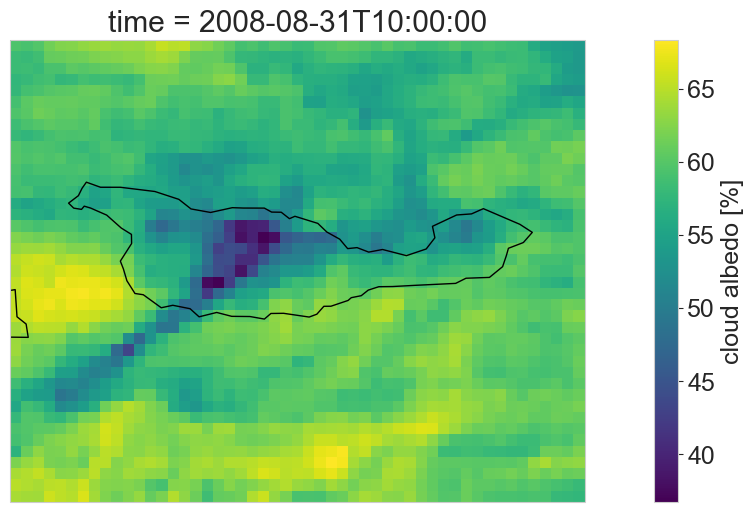

In [33]:
temp = clc_da.sel(time='2008-08-31T10:00:00.000000000')

fig, ax = plt.subplots(1,1, figsize=(18,6), subplot_kw={'projection' : ccrs.PlateCarree()})
temp.plot()
ax.coastlines()
plt.show()

In [34]:
lat_min, lat_max = temp['lat'].max().values, temp['lat'].min().values
lon_min, lon_max = temp['lon'].max().values, temp['lon'].min().values

print(lat_min, lat_max)
print(lon_min, lon_max)

34.2 33.8
-119.48 -119.98


In [35]:
# Format the timestamps
wrf_da['time'] = wrf_da['time'] - pd.to_timedelta(7, unit='h')  # Convert from UTC to PDT
clc_da['time'] = pd.to_datetime(clc_da['time'].values).ceil('30min')  # Round off

In [36]:
# Check that the times are as expected
times = clc_da['time'].to_dataframe().reset_index(drop=True)
times = pd.to_datetime(times['time'])
print(times.dt.hour.unique())

times = wrf_da['time'].to_dataframe().reset_index(drop=True)
times = pd.to_datetime(times['time'])
print(times.dt.hour.unique())

[ 7  8  9 10 11 12 13 14 15 16 17 18 19]
[10 11 12 13 14 15 16 17 18 19 20 21 22 23  0  1  2  3  4  5  6  7  8  9]


In [37]:
# Remove duplicate timestamps - these were just extracted twice
wrf_da = wrf_da.groupby('time').mean()

In [ ]:
# Subset both datasets to intersection of extent of both datasets
latmax, latmin = np.min([wrf_da['lat'].max(), clc_da['lat'].max()]), np.max([wrf_da['lat'].min(), clc_da['lat'].min()])
lonmax, lonmin = np.min([wrf_da['lon'].max(), clc_da['lon'].max()]), np.max([wrf_da['lon'].min(), clc_da['lon'].min()])

#latmax, latmin = 34.2, 33.8
#lonmax, lonmin = -119.48, -119.98

wrf_da = wrf_da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
clc_da = clc_da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))

In [39]:
# Subset each to daylight hours 
common_times = clc_da['time'].values[np.isin(clc_da['time'], wrf_da['time'])]

clc_da = clc_da.sel(time=common_times)
wrf_da = wrf_da.sel(time=common_times)

times = wrf_da['time'].to_dataframe().reset_index(drop=True)
times = pd.to_datetime(times['time'])
times.dt.hour.unique()

array([10, 11, 13, 14, 15, 16, 17, 18, 19,  7,  8,  9, 12], dtype=int32)

## Handle null values

In [40]:
# Check how many timesteps are missing, and if the whole timestep is missing
null_timesteps = clc_da.isnull().any(dim=["lat", "lon"])
clc_da.sel(time=null_timesteps)

<xarray.DataArray 'cldalb' (time: 412, lat: 15, lon: 43)> Size: 1MB
array([[[ 3.43,  4.24, ...,  2.17,  1.98],
        [ 4.09,  5.69, ...,  2.27,  1.97],
        ...,
        [28.7 , 33.23, ..., 69.55, 71.27],
        [32.31, 33.15, ..., 43.25, 43.23]],

       [[ 3.5 ,  4.27, ..., 17.29, 19.86],
        [ 4.41,  5.45, ..., 15.7 , 20.29],
        ...,
        [24.98, 24.47, ..., 19.36, 19.48],
        [14.91, 19.17, ..., 21.35, 21.13]],

       ...,

       [[46.39, 51.8 , ..., 39.59, 55.78],
        [45.18, 55.29, ..., 30.82, 36.81],
        ...,
        [54.47, 66.37, ..., 70.66, 62.7 ],
        [63.87, 68.26, ..., 67.43, 70.91]],

       [[44.73, 48.77, ..., 27.92, 24.65],
        [43.96, 43.51, ..., 27.87, 23.75],
        ...,
        [52.32, 55.28, ..., 29.85, 32.54],
        [48.86, 51.36, ..., 30.83, 32.67]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 344B -119.9 -119.9 -119.9 ... -119.5 -119.5 -119.5
  * lat      (lat) float64 120B 33.95 33.96 33.97 33.98 ... 34.07 34.08 34.09
  * time     (time) datetime64[ns] 3kB 1996-06-03T15:00:00 ... 2017-07-15T08:...
Attributes:
    units:      %
    long_name:  cloud albedo

In [41]:
# Interpolate missing values with the closest
clc_da = clc_da.interpolate_na(dim='time', method="nearest")
clc_da.isnull().sum().values  # Confirm removal of NAs

array(0)

In [42]:
# Check if WRF is missing any values
wrf_da.isnull().sum().values

array(0)

## Align and Join Data

In [43]:
# Align the albedo dataset with wrf dataset
clc_da = clc_da.reindex_like(wrf_da, method='nearest')
ds = xr.Dataset({'albedo' : clc_da, 'low_cloud_frac' : wrf_da})

# Check that realignment didn't introduce NAs
ds.isnull().sum()

<xarray.Dataset> Size: 16B
Dimensions:         ()
Data variables:
    albedo          int64 8B 0
    low_cloud_frac  int64 8B 0

In [44]:
# Remove may 1996 data - only have end of month
ds = ds.sel(time=~((ds.time.dt.year == 1996) & (ds.time.dt.month == 5)))

# Compare Albedo with Low Cloud Fraction

In [45]:
# Extract values for set of points
df = pd.DataFrame()
for i, row in sample_points.iterrows():
    lat = row['Latitude']
    lon = row['Longitude']
    type = row['type']

    site_ds = ds.sel(lat=lat, lon=lon, method='nearest')
    site_df = site_ds.to_dataframe()[['albedo', 'low_cloud_frac']].reset_index()
    site_df['type'] = row['type']
    site_df['station'] = row['Station'] 

    df = pd.concat([df, site_df], axis=0)

df['time'] = pd.to_datetime(df['time'])
df = df.reset_index(drop=True)
df.head()

# Create binary cloud/no cloud
df['clc-binary'] = df['albedo'].apply(lambda x : 1 if x > 8.5 else 0)

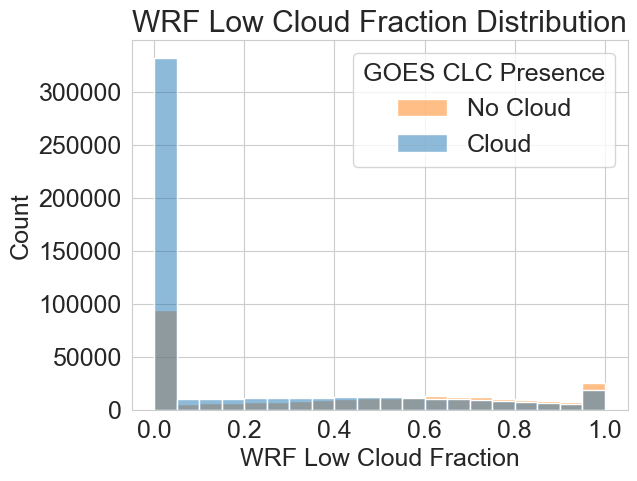

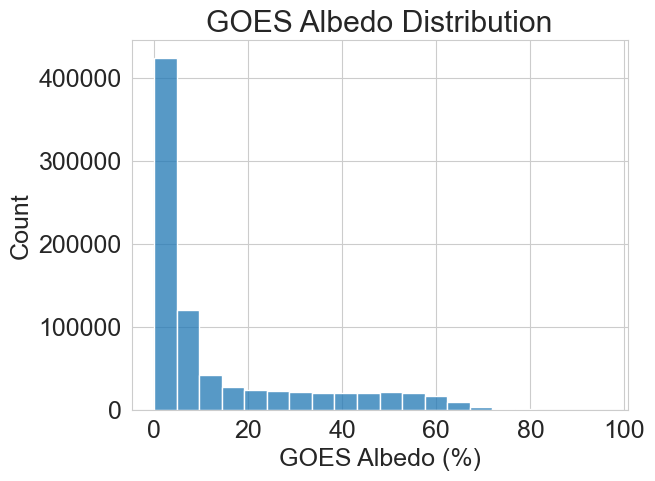

In [46]:
# Check Distribution of wrf low cloud fraction
fig, ax = plt.subplots()
sns.histplot(df, x='low_cloud_frac', bins=20, hue='clc-binary', ax=ax)
ax.set(title='WRF Low Cloud Fraction Distribution',
       xlabel='WRF Low Cloud Fraction')
plt.legend(title='GOES CLC Presence', labels=['No Cloud', 'Cloud'])
plt.show()

fig, ax = plt.subplots()
sns.histplot(df, x='albedo', bins=20)
ax.set(title='GOES Albedo Distribution',
       xlabel='GOES Albedo (%)')
plt.show()

Correlation: 0.3002323639110901


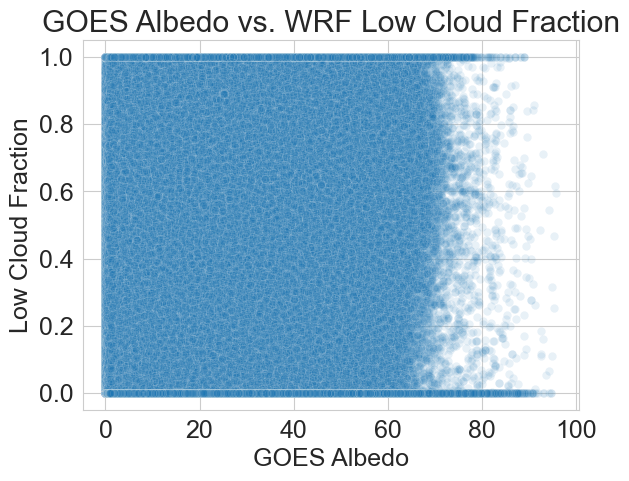

In [47]:
# Check relationship between Albedo and Low Cloud
correlation = df['albedo'].corr(df['low_cloud_frac'])

print(f'Correlation: {correlation}')
fig, ax = plt.subplots()
sns.scatterplot(data=df,
                x='albedo',
                y='low_cloud_frac',
                alpha=0.1)
ax.set(title='GOES Albedo vs. WRF Low Cloud Fraction',
       xlabel='GOES Albedo',
       ylabel='Low Cloud Fraction')
plt.show()

# Assess WRF Cloud Fraction Threshold 

In [48]:
# Create regions of interest
root_dir = Path().resolve().parents[0]
roi_fpath = root_dir / 'data' / 'geospatial' / 'roi-boundaries' / 'roi-boundaries-copy.shp'
roi_gdf = gpd.read_file(roi_fpath)
roi_df = roi_gdf.drop('geometry', axis=1)

ds_fpath = root_dir / 'data' / 'wrf-low-cloud' / 'wrf-low-cld-processed-partial-1.nc'
ds = xr.open_dataset(ds_fpath)

# Define centers of regions of interest
site_dict = {
    'site' : ['west-end', 'coche-point', 'inland', 'north-ocean'],
    'lat' : [34.012499, 34.033456, 34.00346, 34.08375],
    'lon' : [-119.882897, -119.600946, -119.76288, -119.68265]
}

site_df = pd.DataFrame(site_dict)

# Get regions of interest using centers
bounds_df = pd.DataFrame()
for i, site in site_df.iterrows():
    bounds_df = pd.concat([bounds_df, get_bounds(ds, site)])

site_df = site_df.merge(bounds_df, on='site')

In [49]:
# Get frequencies for range of cloud fraction thresholds 
thresholds = np.arange(0, 1.05, 0.05)
ds['alb_binary'] = xr.where(ds['albedo'] > 8.5, 1, 0)

freq_df = pd.DataFrame()
for threshold in thresholds: 
    ds['wrf_binary'] = xr.where(ds['low_cloud_frac'] > threshold, 1, 0)
    ds['match'] = xr.where((ds['alb_binary'] == ds['wrf_binary']), 1, 0)
    df = get_freq(ds, roi_df)
    df['threshold'] = threshold
    freq_df = pd.concat([freq_df, df])

freq_df

,site,goes_freq,wrf_freq,match_freq,threshold
0,overall,37.920690,55.843337,62.053737,0.0
0,west-end,51.931631,79.931038,59.420037,0.0
0,coche-point,49.151201,45.092624,66.113707,0.0
0,inland,23.998907,21.579636,73.754980,0.0
0,north-ocean,36.567633,65.527047,59.304957,0.0
...,...,...,...,...,...
0,overall,37.920690,0.000000,62.079310,1.0
0,west-end,51.931631,0.000000,48.068369,1.0
0,coche-point,49.151201,0.000000,50.848799,1.0
0,inland,23.998907,0.000000,76.001093,1.0


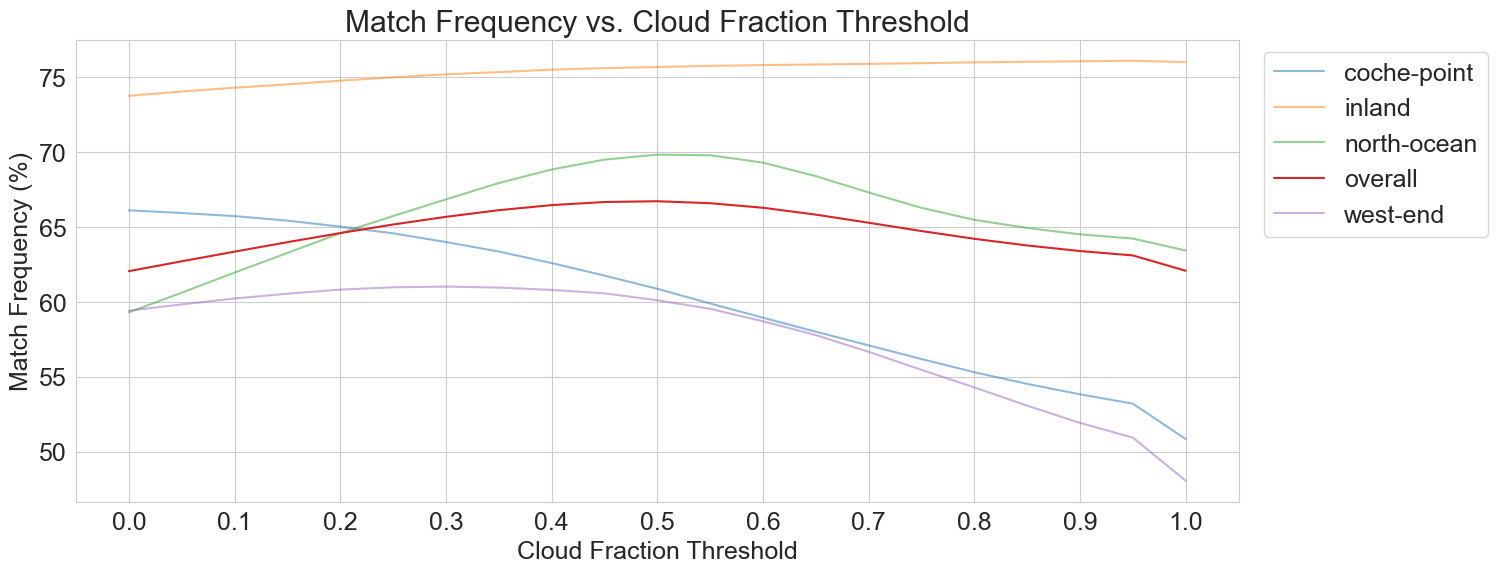

In [50]:
# Plot match against cloud fraction thresholds

# Create a dictionary for alpha values
alpha_map = {hue: 0.5 if hue != 'overall' else 1 for hue in freq_df['site'].unique()}

# Plot Match Frequency vs. Cloud Frac
fig, ax = plt.subplots(figsize=(15,6))
for site, subset in freq_df.groupby('site'):
    sns.lineplot(data=subset, x='threshold', y='match_freq', label=site, alpha=alpha_map[site], ax=ax)
ax.set(title='Match Frequency vs. Cloud Fraction Threshold',
    xlabel='Cloud Fraction Threshold',
    ylabel=f'Match Frequency (%)')
ax.set_xticks(np.arange(0,1.05,0.1))
plt.legend(loc='upper right', bbox_to_anchor=(1.225, 1))
plt.show()

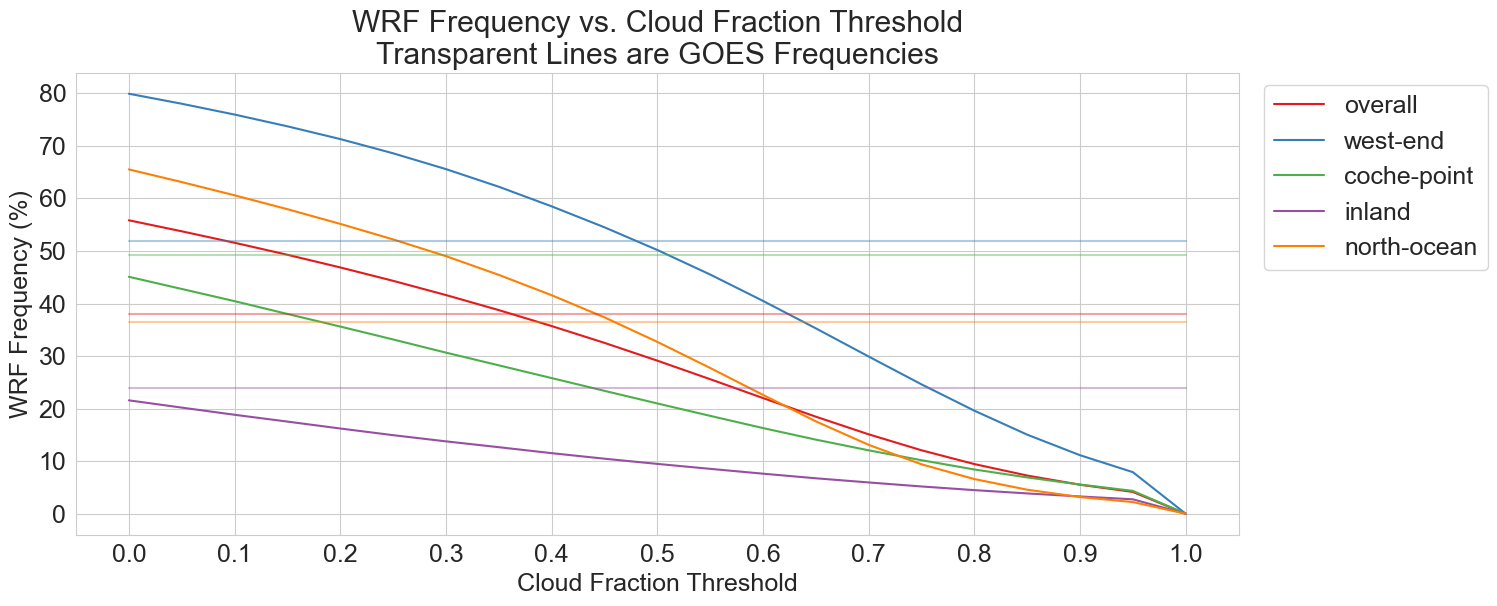

In [51]:
# Plot WRF frequenceis against thresholds

# Define color map for sites
unique_sites = freq_df['site'].unique()
palette = dict(zip(unique_sites, sns.color_palette('Set1', len(unique_sites))))

# Plot WRF Frequency vs. Cloud Frac
fig, ax = plt.subplots(figsize=(15,6))
sns.lineplot(data=freq_df,
             x='threshold',
             y='wrf_freq',
             hue='site',
             palette=palette)
sns.lineplot(data=freq_df,
             x='threshold',
             y='goes_freq',
             hue='site',
             palette=palette,
             alpha=0.4,
             legend=False)


ax.set(title='WRF Frequency vs. Cloud Fraction Threshold\nTransparent Lines are GOES Frequencies',
    xlabel='Cloud Fraction Threshold',
    ylabel=f'WRF Frequency (%)')
ax.set_xticks(np.arange(0,1.05,0.1))
plt.legend(loc='upper right', bbox_to_anchor=(1.225, 1))
plt.show()

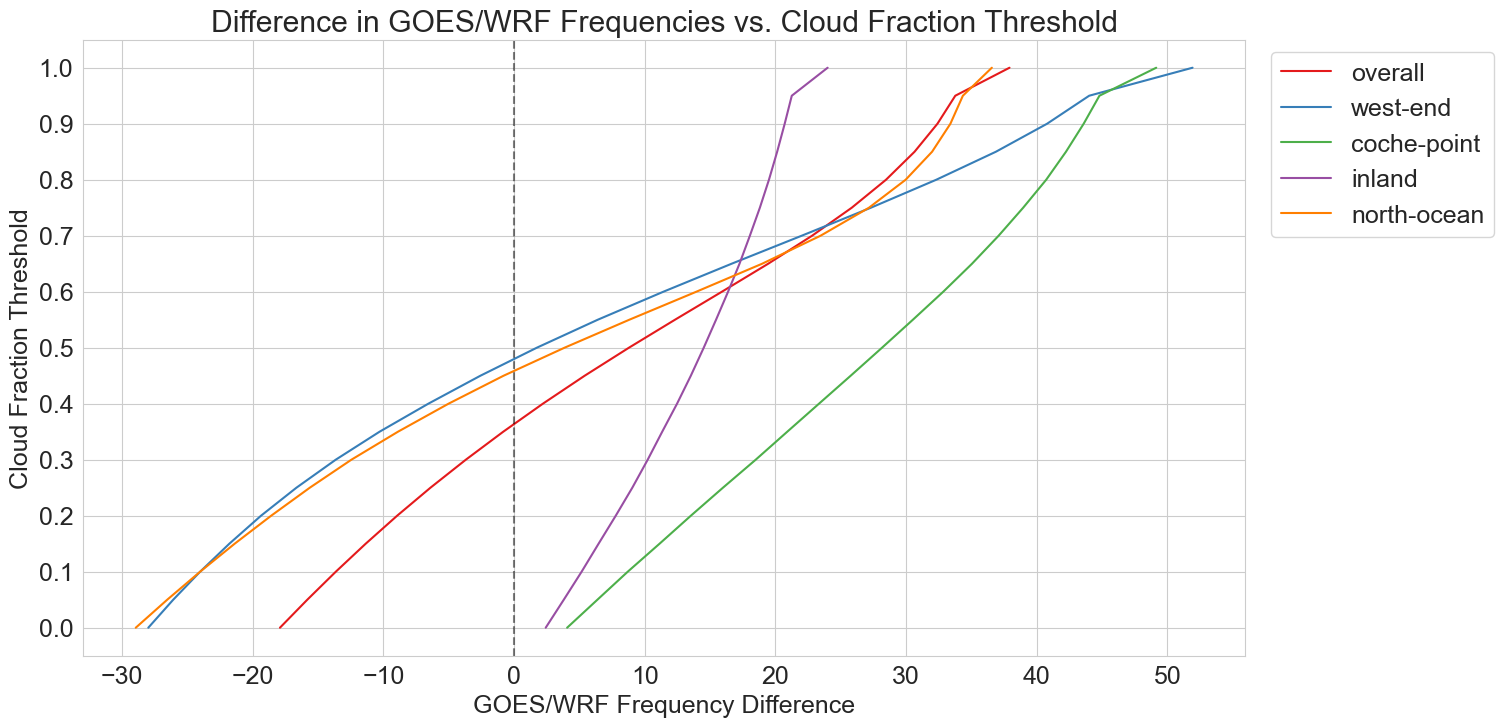

In [52]:
freq_df['diff'] = freq_df['goes_freq'] - freq_df['wrf_freq']

fig, ax = plt.subplots(figsize=(15,8))
sns.lineplot(data=freq_df,
             x='diff',
             y='threshold',
             hue='site',
             palette=palette,
             ax=ax)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set(title='Difference in GOES/WRF Frequencies vs. Cloud Fraction Threshold',
       xlabel='GOES/WRF Frequency Difference',
       ylabel='Cloud Fraction Threshold')
ax.set_yticks(np.arange(0,1.05,0.1))
plt.legend(loc='upper right', bbox_to_anchor=(1.225, 1))
plt.show()

In [53]:
# Save out processed dataset
cld_frc_threshold = 0.45  # Based on plots above

# Create binary
ds['alb_binary'] = xr.where(ds['albedo'] > 8.5, 1, 0)
ds['wrf_binary'] = xr.where(ds['low_cloud_frac'] > cld_frc_threshold, 1, 0)
ds['match'] = xr.where((ds['alb_binary'] == ds['wrf_binary']), 1, 0)

# Save out processed dataset
fpath = root_dir / 'data' / 'wrf-low-cloud' / 'wrf-low-cld-processed-partial.nc'
ds.to_netcdf(fpath)

# Analyses

In [54]:
root_dir = Path().resolve().parents[0]
fpath = root_dir / 'data' / 'wrf-low-cloud' / 'wrf-low-cld-processed-partial.nc'
ds = xr.open_dataset(fpath)

## Spatial Analyses

### All Data Aggregated
Compare WRF / GOES for the whole dataset

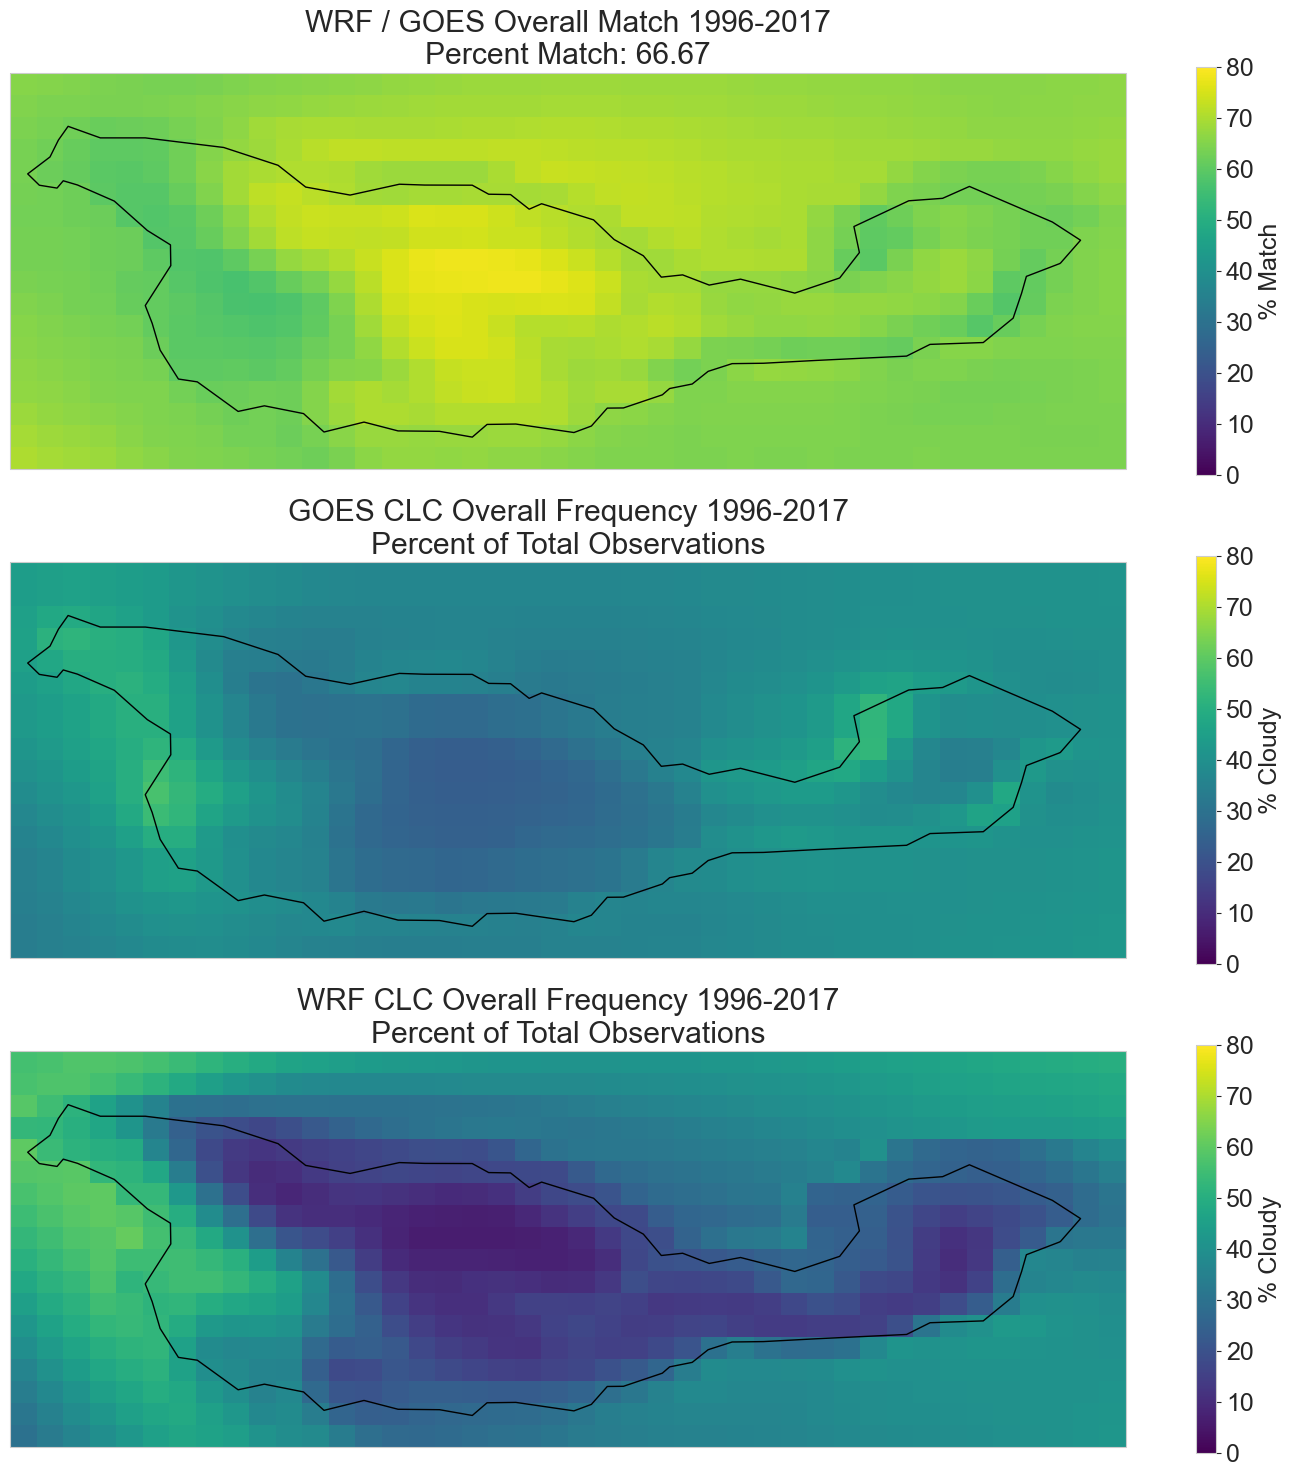

In [55]:
min_year = int(ds['time'].min().dt.year)
max_year = int(ds['time'].max().dt.year)

# Group over all timesteps
ds_gp = ds.sum('time')
total_count = ds.count('time')
ds_gp = (ds_gp / total_count) * 100

# Get match % statistic
perc_match = round(float(ds_gp['match'].mean()),2)

# Plot data
fig, ax = plt.subplots(3, 1, figsize=(18, 18), subplot_kw={'projection': ccrs.PlateCarree()})
cbar_scale = 1

norm1 = mcolors.Normalize(vmin=0, vmax=80)  # Normalize color bar range
norm2 = mcolors.Normalize(vmin=0, vmax=80)

## Plot match %
var = 'match'
ds_gp[var].plot(ax=ax[0], cbar_kwargs={"shrink": cbar_scale, "label": "% Match"}, norm=norm1)
ax[0].set(title=f'WRF / GOES Overall Match {min_year}-{max_year}\nPercent Match: {perc_match}')
ax[0].coastlines()

## Plot GOES frequencies
var = 'alb_binary'
ds_gp[var].plot(ax=ax[1], cbar_kwargs={"shrink": cbar_scale, "label": "% Cloudy"}, norm=norm2)
ax[1].set(title=f'GOES CLC Overall Frequency {min_year}-{max_year}\nPercent of Total Observations')
ax[1].coastlines()    

## Plot WRF frequencies
var = 'wrf_binary'
ds_gp[var].plot(ax=ax[2], cbar_kwargs={"shrink": cbar_scale, "label": "% Cloudy"}, norm=norm2)
ax[2].set(title=f'WRF CLC Overall Frequency {min_year}-{max_year}\nPercent of Total Observations')
ax[2].coastlines()

plt.show()

### Month Average Plots

In [56]:
min_year = int(ds['time'].min().dt.year)
max_year = int(ds['time'].max().dt.year)

# Group by month - average over all years
months_ds = ds.groupby('time.month').sum('time')
months_count = ds.groupby('time.month').count('time')
months_ds = (months_ds / months_count) * 100

# Function to create single plot for each month
def plot_monthly(months_ds, month, fpath=None):
    # Get the overall match % for given month
    perc_match = round(float(months_ds['match'].sel(month=month).mean()),2)

    # Create map
    fig, ax = plt.subplots(3, 1, figsize=(18, 18), subplot_kw={'projection': ccrs.PlateCarree()})
    cbar_scale = 1
    
    norm1 = mcolors.Normalize(vmin=0, vmax=80)  # Specify color ramp range
    norm2 = mcolors.Normalize(vmin=0, vmax=65)
    
    ## Plot match %
    var = 'match'
    months_ds[var].sel(month=month).plot(ax=ax[0], cbar_kwargs={"shrink": cbar_scale, "label": "% Match"}, norm=norm1)
    ax[0].set(title=f'WRF / GOES Match {min_year}-{max_year}\nMonth {month}\nPercent Match: {perc_match}')
    ax[0].coastlines()

    ## Plot GOES frequencies
    var = 'alb_binary'
    months_ds[var].sel(month=month).plot(ax=ax[1], cbar_kwargs={"shrink": cbar_scale, "label": "% Cloudy"}, norm=norm2)
    ax[1].set(title=f'{month} - GOES CLC Frequency {min_year}-{max_year}\nPercent of Total Observations')
    ax[1].coastlines()    

    ## Plot WRF frequencies
    var = 'wrf_binary'
    months_ds[var].sel(month=month).plot(ax=ax[2], cbar_kwargs={"shrink": cbar_scale, "label": "% Cloudy"}, norm=norm2)
    ax[2].set(title=f'{month} - WRF CLC Frequency {min_year}-{max_year}\nPercent of Total Observations')
    ax[2].coastlines()

    ## Either save or display figure
    if fpath:
        plt.savefig(fpath)
    else:
        plt.show()

    plt.close()

# Save out a plot for each month
out_dir = root_dir / 'outputs' / 'goes-plots' / 'agg-monthly-match'
months = list(months_ds['month'].values)
for month in months:
    out_fpath = out_dir / f'{month}-match-perc.png'
    plot_monthly(months_ds, month, fpath=out_fpath)
print(f'Saved plots out to {out_dir}')

Saved plots out to /Users/patmccornack/Documents/ucsb_fog_project/_repositories/sci-wrf-analysis/outputs/goes-plots/agg-monthly-match


### Aggregated Year Plots

In [57]:
min_year = int(ds['time'].min().dt.year)
max_year = int(ds['time'].max().dt.year)

# Group by year, and get average value for each year
years_ds = ds.groupby('time.year').sum('time')
years_count = ds.groupby('time.year').count('time')
years_ds = (years_ds / years_count) * 100

# Function to create plot for each year
def plot_yearly(years_ds, year, fpath=None):
    # Get match % for given year
    perc_match = round(float(years_ds['match'].sel(year=year).mean()),2)

    # Create map
    fig, ax = plt.subplots(3, 1, figsize=(18, 18), subplot_kw={'projection': ccrs.PlateCarree()})
    cbar_scale = 1
    
    norm1 = mcolors.Normalize(vmin=0, vmax=80)  # Specify color ramp range
    norm2 = mcolors.Normalize(vmin=0, vmax=65)
    
    ## Plot match %
    var = 'match'
    years_ds[var].sel(year=year).plot(ax=ax[0], cbar_kwargs={"shrink": cbar_scale, "label": "% Match"}, norm=norm1)
    ax[0].set(title=f'WRF / GOES Match {min_year}-{max_year}\n{year}\nPercent Match: {perc_match}')
    ax[0].coastlines()

    ## Plot GOES frequency
    var = 'alb_binary'
    years_ds[var].sel(year=year).plot(ax=ax[1], cbar_kwargs={"shrink": cbar_scale, "label": "% Cloudy"}, norm=norm2)
    ax[1].set(title=f'{year} - GOES CLC Frequency {min_year}-{max_year}\nPercent of Total Observations')
    ax[1].coastlines()    

    ## Plot WRF frequency
    var = 'wrf_binary'
    years_ds[var].sel(year=year).plot(ax=ax[2], cbar_kwargs={"shrink": cbar_scale, "label": "% Cloudy"}, norm=norm2)
    ax[2].set(title=f'{year} - WRF CLC Frequency {min_year}-{max_year}\nPercent of Total Observations')
    ax[2].coastlines()

    if fpath:
        plt.savefig(fpath)
    else:
        plt.show()

    plt.close()

# Save out plot for each year
out_dir = root_dir / 'outputs' / 'goes-plots' / 'agg-yearly-match'
years = list(years_ds['year'].values)
for year in years:
    out_fpath = out_dir / f'{year}-match-perc'
    plot_yearly(years_ds, year, fpath=out_fpath)
print(f'Saved plots out to {out_dir}')

Saved plots out to /Users/patmccornack/Documents/ucsb_fog_project/_repositories/sci-wrf-analysis/outputs/goes-plots/agg-yearly-match


### Month by Month Plots

In [58]:
# Group by year/month combination
gp_ds = ds.groupby(['time.year', 'time.month']).sum()
count_ds = ds.groupby(['time.year', 'time.month']).count()
gp_ds = gp_ds / count_ds * 100

# Function to create plot for each year/month combination
def plot_monthly(gp_da, year, month, fpath=None):
    # Get overall % match for each year/month
    perc_match = round(float(gp_da['match'].sel(year=year, month=month).mean()),2)

    # Create map 
    fig, ax = plt.subplots(3, 1, figsize=(18, 18), subplot_kw={'projection': ccrs.PlateCarree()})
    cbar_scale = 1

    norm1 = mcolors.Normalize(vmin=0, vmax=80)  # Specify color ramp range
    norm2 = mcolors.Normalize(vmin=0, vmax=65)
    
    ## Create % match map
    var = 'match'
    gp_da[var].sel(year=year, month=month).plot(ax=ax[0], cbar_kwargs={"shrink": cbar_scale, "label": "% Match"}, norm=norm1)
    ax[0].set(title=f'WRF / GOES Match \n{month}-{year}\nPercent Match: {perc_match}')
    ax[0].coastlines()

    ## Create GOES frequency map
    var = 'alb_binary'
    gp_da[var].sel(year=year, month=month).plot(ax=ax[1], cbar_kwargs={"shrink": cbar_scale, "label": "% Cloudy"}, norm=norm2)
    ax[1].set(title=f'{month}-{year} - GOES CLC Frequency\nPercent of Total Observations')
    ax[1].coastlines()    

    ## Create WRF frequency map
    var = 'wrf_binary'
    gp_da[var].sel(year=year, month=month).plot(ax=ax[2], cbar_kwargs={"shrink": cbar_scale, "label": "% Cloudy"}, norm=norm2)
    ax[2].set(title=f'{month}-{year} - WRF CLC Frequency\nPercent of Total Observations')
    ax[2].coastlines()

    if fpath:
        plt.savefig(fpath)
    else:
        plt.show()

    plt.close()

# Create plot for every year/month in dataset
out_dir = root_dir / 'outputs' / 'goes-plots' / 'month-match'
years = list(gp_ds['year'].values)
months = list(gp_ds['month'].values)
for year in years:
    for month in months:
        out_fpath = out_dir / f'{year}-{month}-match-perc'
        plot_monthly(gp_ds, year, month, fpath=out_fpath)
print(f'Saved plots out to {out_dir}')

Saved plots out to /Users/patmccornack/Documents/ucsb_fog_project/_repositories/sci-wrf-analysis/outputs/goes-plots/month-match


## Temporal Analysis Plots

### Interannual Comparisons

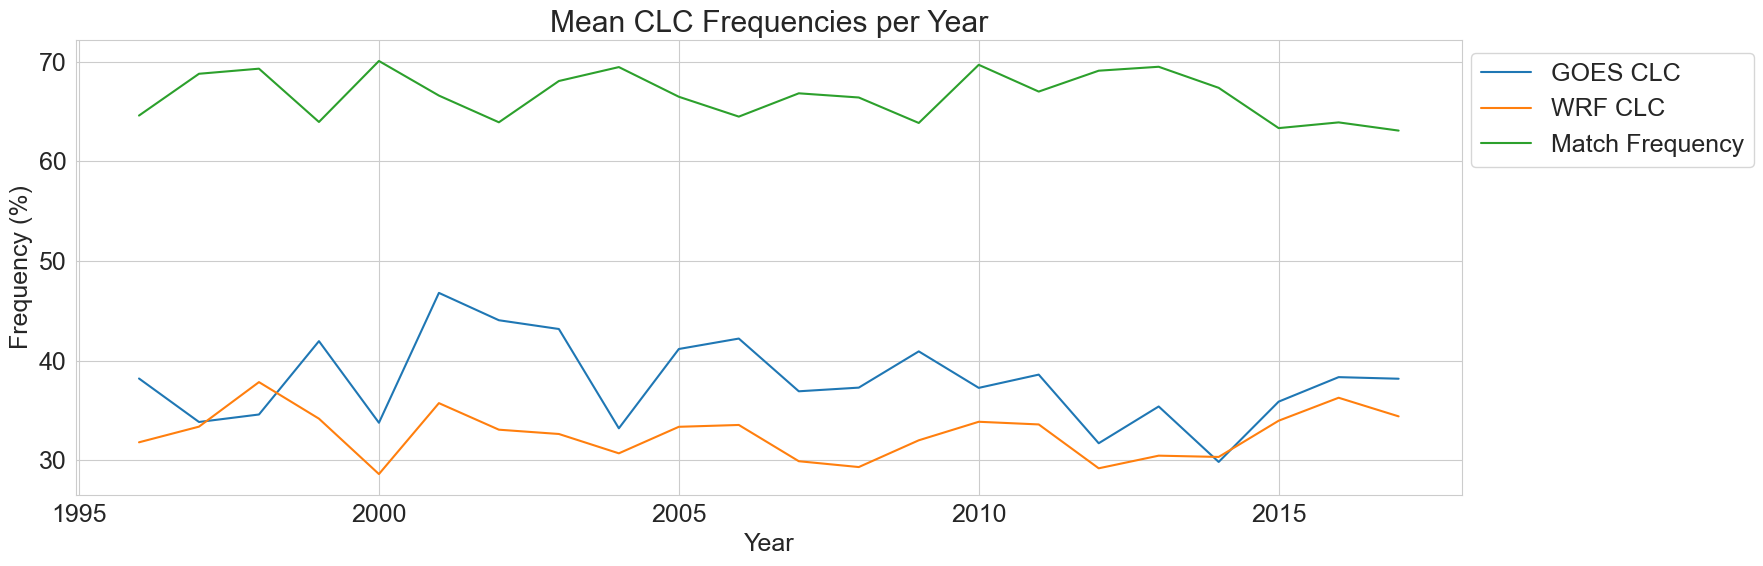

In [61]:
ds_gp = ds.groupby('time.year').sum()
total_count = ds.groupby('time.year').count()
ds_gp = ds_gp / total_count * 100
ds_gp = ds_gp.groupby('year').mean(dim=['lat', 'lon'])
df_gp = ds_gp[['alb_binary', 'wrf_binary']].to_dataframe()

fig, ax = plt.subplots(figsize=(18,6))
sns.lineplot(data=df_gp,
             x='year',
             y='alb_binary',
             label='GOES CLC')
sns.lineplot(data=df_gp,
             x='year',
             y='wrf_binary',
             label='WRF CLC')
sns.lineplot(data=match_df,
            x='year',
            y='match',
            label='Match Frequency')
ax.set(title='Mean CLC Frequencies per Year',
       xlabel='Year',
       ylabel='Frequency (%)')
plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1))
plt.tight_layout()
plt.show()

### Intermonth Comparison

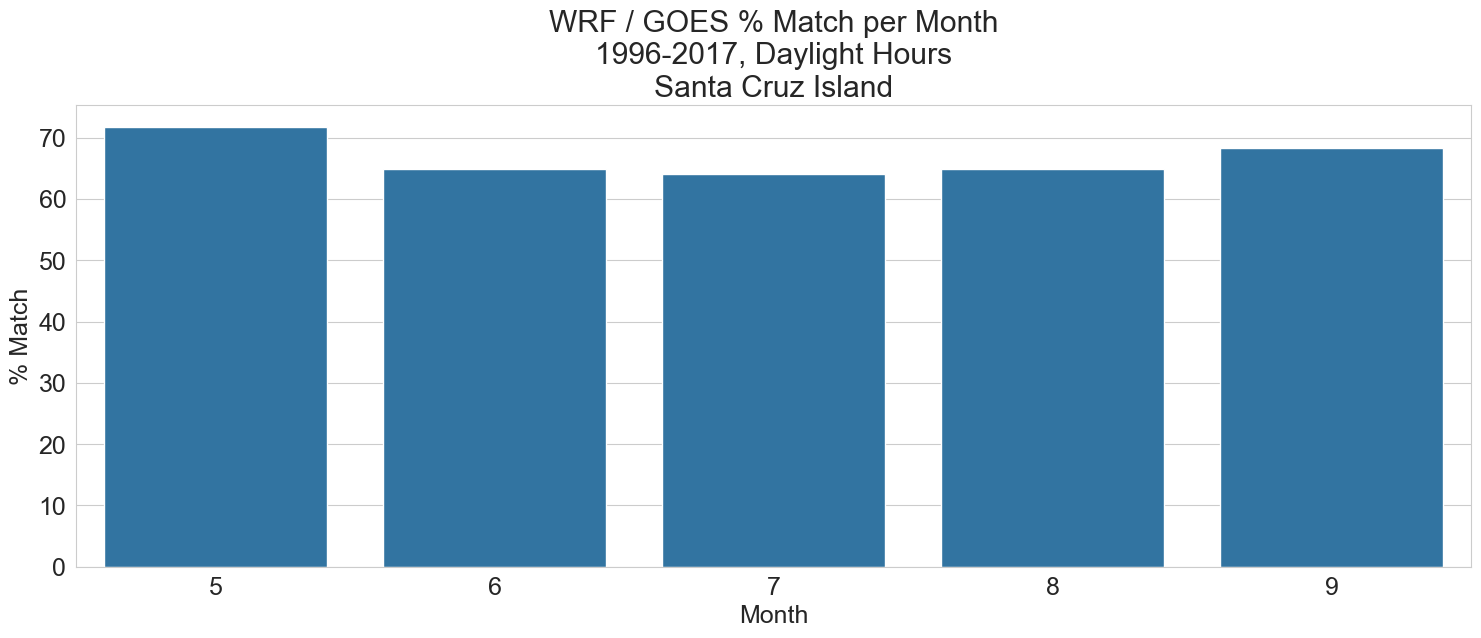

In [62]:
# Bar plot of % match per month
min_year = int(ds['time'].min().dt.year)
max_year = int(ds['time'].max().dt.year)

months_ds = ds.groupby('time.month').sum('time')
months_count = ds.groupby('time.month').count('time')
months_ds = (months_ds / months_count) * 100

match_da = months_ds['match']
match_da = match_da.groupby('month').mean(dim=['lat', 'lon'])

match_df = match_da.to_dataframe()

fig, ax = plt.subplots(figsize=(18, 6))
sns.barplot(data=match_df,
            x='month',
            y='match')

ax.set(title=f'WRF / GOES % Match per Month\n{min_year}-{max_year}, Daylight Hours\nSanta Cruz Island',
       xlabel='Month',
       ylabel='% Match')
plt.show()

### Month/Year Comparisons

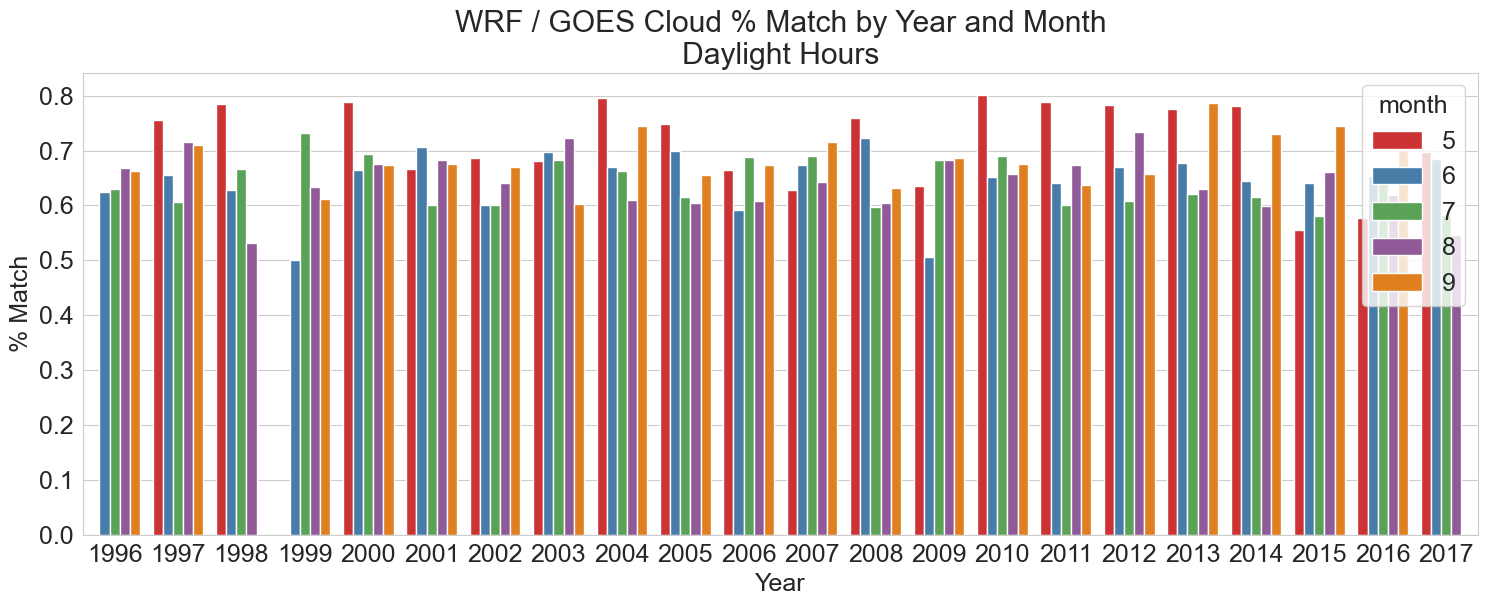

In [63]:
# Bar plot breaking down % match per year, stratified by month
gp_ds = ds.groupby(['time.year', 'time.month']).mean(dim=['time', 'lat', 'lon'])
gp_df = gp_ds['match'].to_dataframe()
gp_df['year'] = gp_df.index.get_level_values(0)
gp_df['month'] = gp_df.index.get_level_values(1)
gp_df = gp_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(18,6))
sns.barplot(data=gp_df,
            x='year',
            y='match',
            hue='month',
            palette='Set1')
ax.set(title='WRF / GOES Cloud % Match by Year and Month\nDaylight Hours',
       xlabel='Year',
       ylabel='% Match')
plt.show()

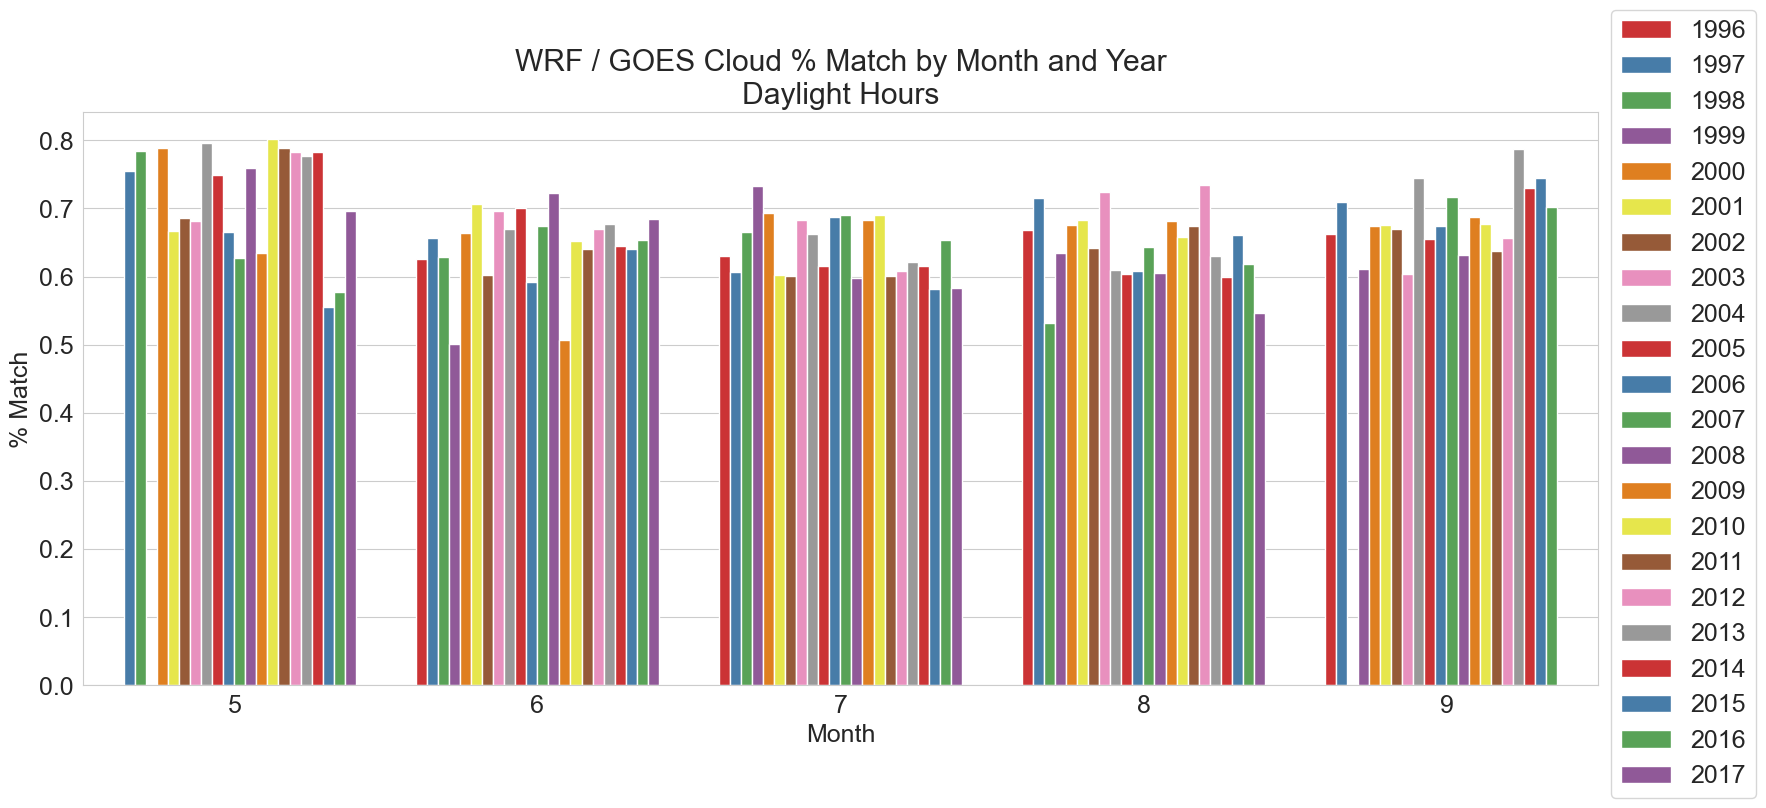

In [64]:
# Bar plot breaking down % match per month, stratified by year
gp_ds = ds.groupby(['time.year', 'time.month']).mean(dim=['time', 'lat', 'lon'])
gp_df = gp_ds['match'].to_dataframe()
gp_df['year'] = gp_df.index.get_level_values(0)
gp_df['month'] = gp_df.index.get_level_values(1)
gp_df = gp_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(18,8))
sns.barplot(data=gp_df,
            x='month',
            y='match',
            hue='year',
            palette='Set1')
ax.set(title='WRF / GOES Cloud % Match by Month and Year\nDaylight Hours',
       xlabel='Month',
       ylabel='% Match')
ax.legend(loc='upper left', bbox_to_anchor=(1,1.2))
plt.tight_layout()
plt.show()

# ROI Analysis

In [65]:
# Create regions of interest
root_dir = Path().resolve().parents[0]
roi_fpath = root_dir / 'data' / 'geospatial' / 'roi-boundaries' / 'roi-boundaries-copy.shp'
roi_gdf = gpd.read_file(roi_fpath)
roi_df = roi_gdf.drop('geometry', axis=1)

ds_fpath = root_dir / 'data' / 'wrf-low-cloud' / 'wrf-low-cld-processed-partial-1.nc'
ds = xr.open_dataset(ds_fpath)

# Define centers of regions of interest
site_dict = {
    'site' : ['west-end', 'coche-point', 'inland', 'north-ocean'],
    'lat' : [34.012499, 34.033456, 34.00346, 34.08375],
    'lon' : [-119.882897, -119.600946, -119.76288, -119.68265]
}

site_df = pd.DataFrame(site_dict)

# Get regions of interest using centers
bounds_df = pd.DataFrame()
for i, site in site_df.iterrows():
    bounds_df = pd.concat([bounds_df, get_bounds(ds, site)])

site_df = site_df.merge(bounds_df, on='site')
site_df

,site,lat,lon,lat_min,lat_max,lon_min,lon_max,bounds
0,west-end,34.012499,-119.882897,33.996543,34.022378,-119.898397,-119.867236,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
1,coche-point,34.033456,-119.600946,34.022376,34.048196,-119.617971,-119.586810,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
2,inland,34.003460,-119.762880,33.987937,34.013772,-119.773763,-119.742602,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
3,north-ocean,34.083750,-119.682650,34.073996,34.099816,-119.701055,-119.669902,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...


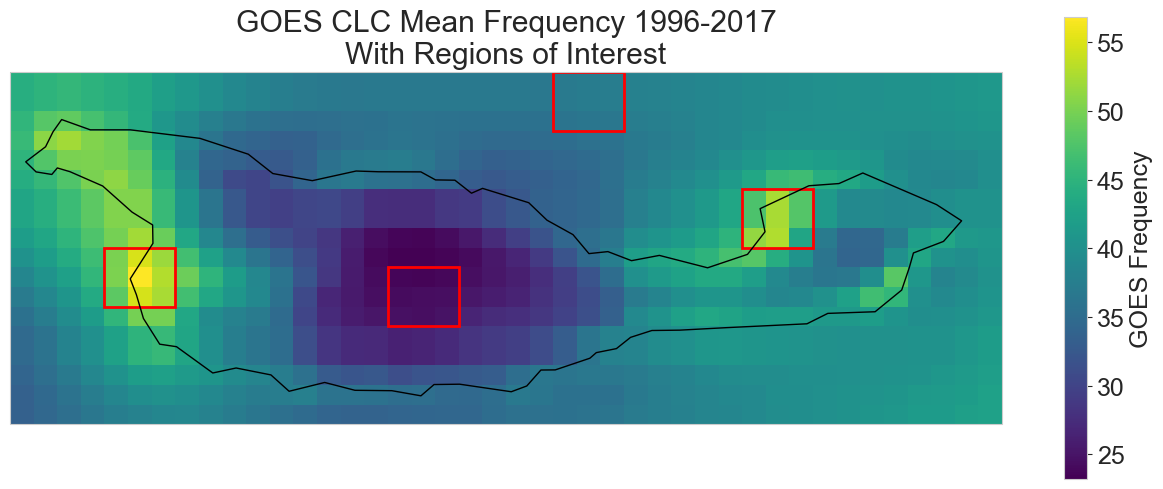

In [66]:
# Plot regions of interest
min_year = int(ds['time'].min().dt.year)
max_year = int(ds['time'].max().dt.year)

# Group over entire dataset
ds_gp = ds.sum('time')
total_count = ds.count('time')
ds_gp = (ds_gp / total_count) * 100
goes_da = ds_gp['alb_binary']

# Plot regions of interest over GOES frequencies
fig, ax = plt.subplots(figsize=(16,6), subplot_kw={'projection': ccrs.PlateCarree()})
goes_da.plot(ax=ax, cbar_kwargs={"shrink": 1, "label": "GOES Frequency"})
for i, site in site_df.iterrows():
    polygon = Polygon(site['bounds'], closed=True, edgecolor='red', facecolor='none', linewidth=2)
    ax.add_patch(polygon)
ax.set(title=f'GOES CLC Mean Frequency {min_year}-{max_year}\nWith Regions of Interest')
ax.coastlines()
plt.show()

## Bar Plots

### Full dataset frequencies

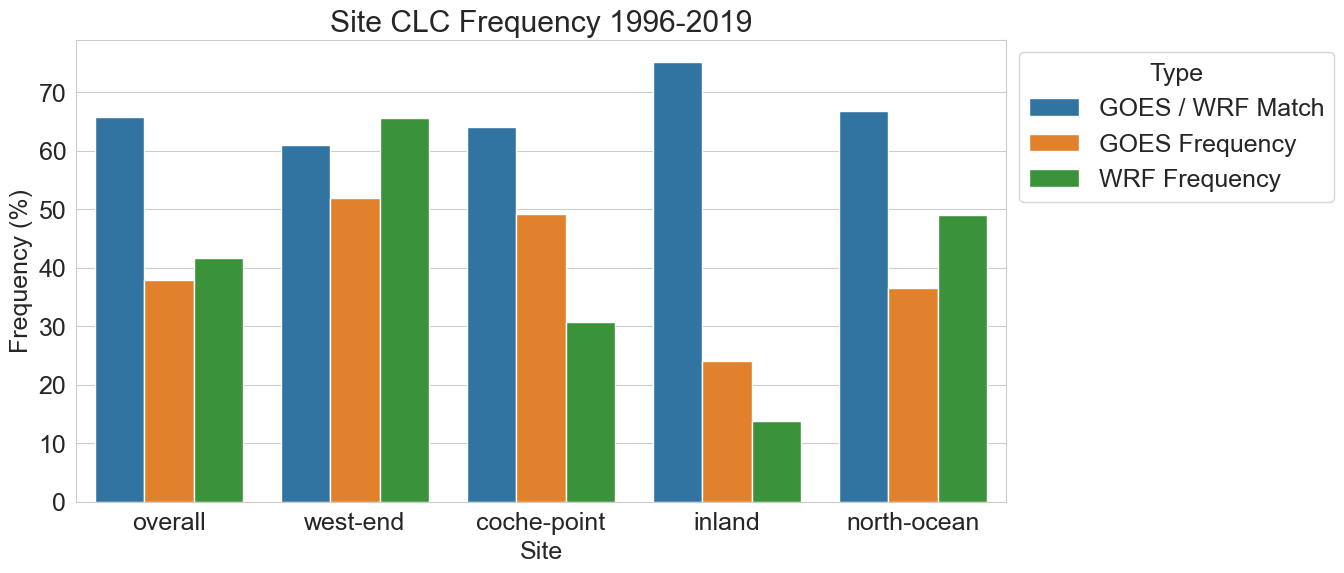

In [ ]:
# Get frequencies
freq_df = get_freq(ds, roi_df)

# Cast to long
freq_df_long = freq_df.melt(id_vars='site', var_name='type', value_name='frequency')

# Plot frequencies by ROI
## Create barplot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=freq_df_long,
            x='site',
            y='frequency',
            hue='type',
            hue_order=['match_freq', 'goes_freq', 'wrf_freq'],
            ax=ax)
ax.set(title='Site CLC Frequency 1996-2019',
       xlabel='Site',
       ylabel='Frequency (%)')

## Specify legend
handles, labels = ax.get_legend_handles_labels()
custom_labels = ["GOES / WRF Match", "GOES Frequency", "WRF Frequency"]
ax.legend(handles, custom_labels, title="Type", loc='upper left', 
          bbox_to_anchor=(1, 1))

plt.show()


### ROI Frequencies by Month

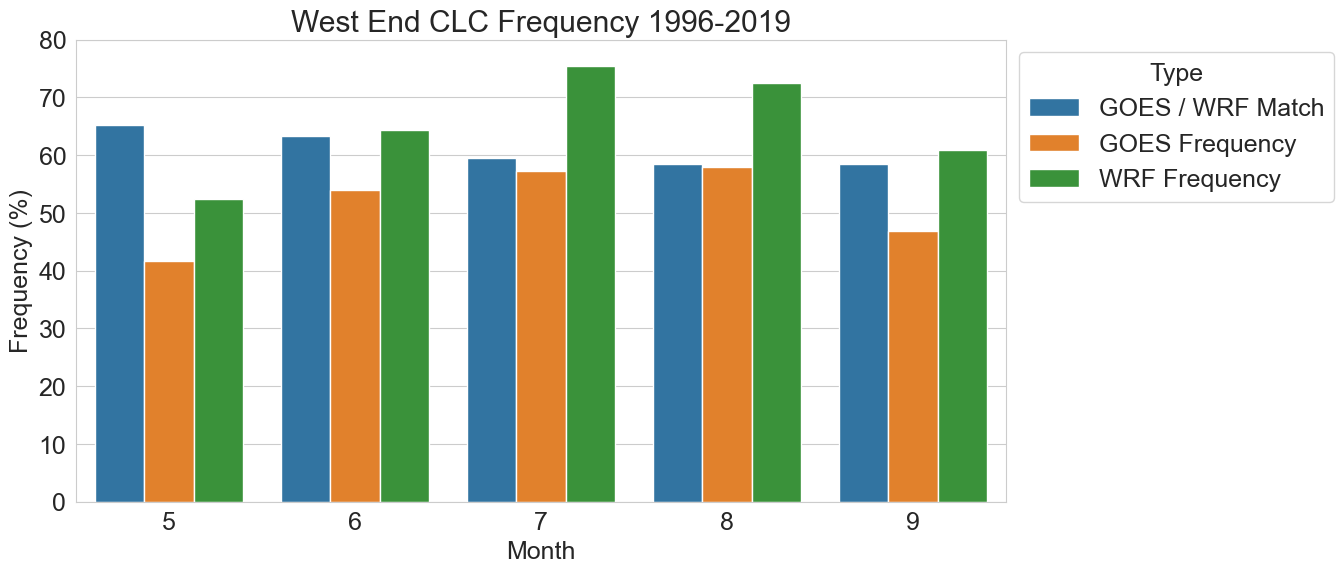

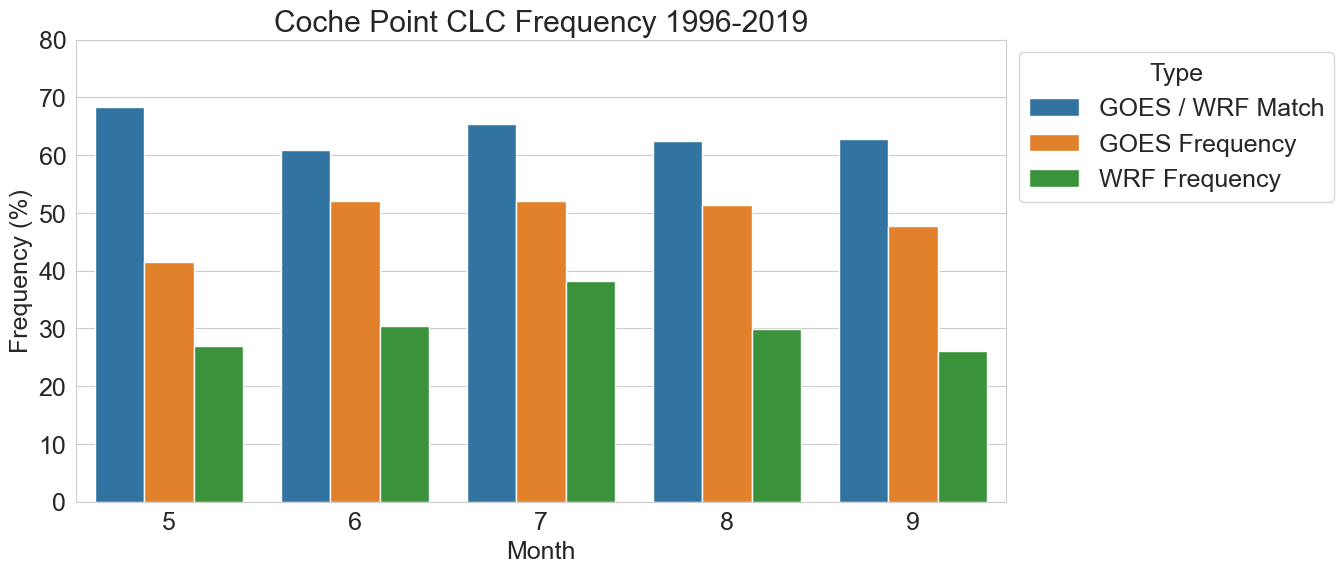

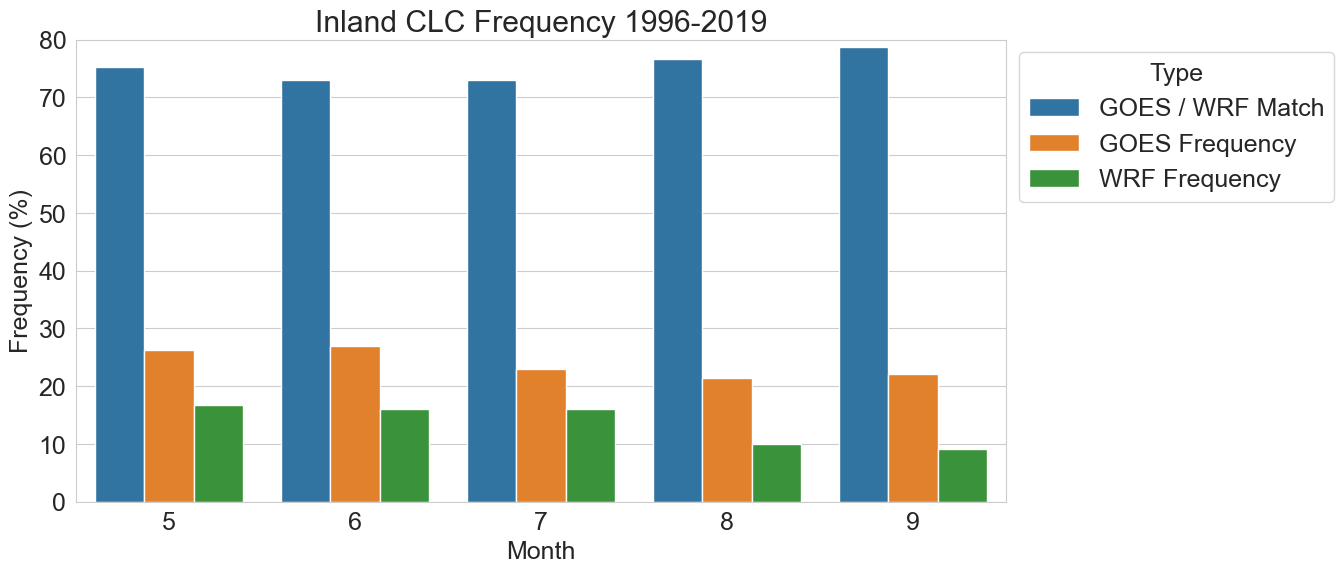

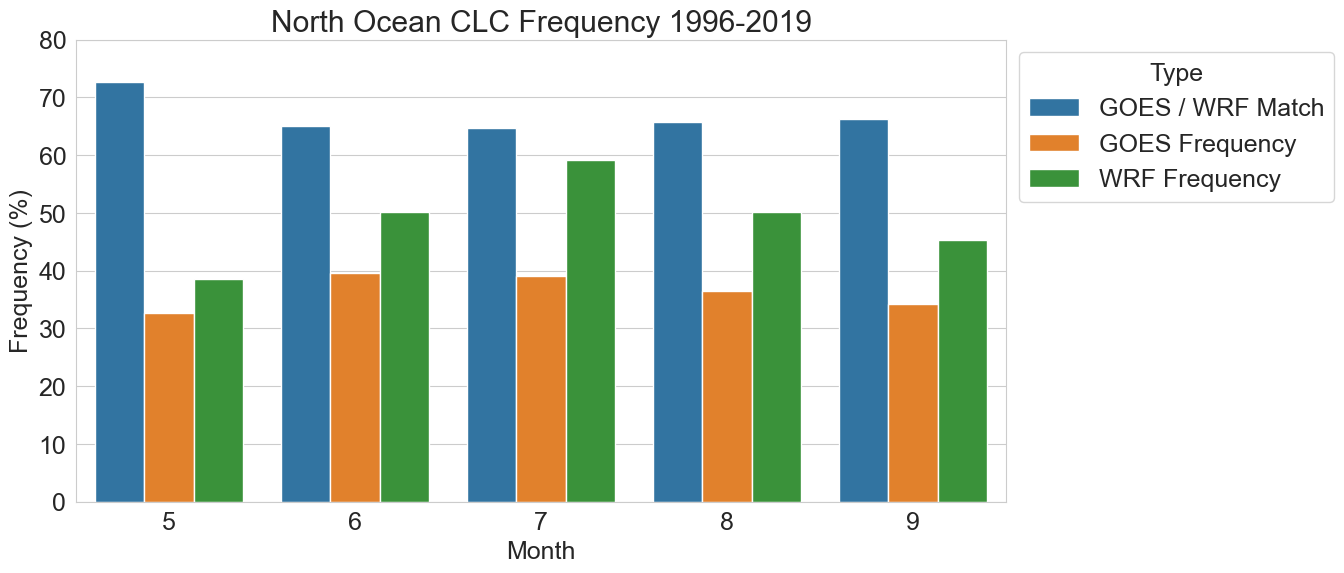

In [ ]:
# Get monthly frequencies
freq_df = get_monthly_freq(ds, roi_df)

# Plot ROI mean frequencies by month
for site in freq_df['site'].unique().tolist():
    site_freq_df = freq_df.loc[freq_df['site'] == site].drop('site', axis=1)
    site_freq_df_long = site_freq_df.melt(id_vars='month', var_name='type', value_name='frequency')

    norm1 = mcolors.Normalize(vmin=0, vmax=80)  # Normalize color bar range

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=site_freq_df_long,
                x='month',
                y='frequency',
                hue='type',
                hue_order=['match_freq', 'goes_freq', 'wrf_freq'],
                ax=ax)
    ax.set_ylim(0,80)


    # Customize legend labels
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ["GOES / WRF Match", "GOES Frequency", "WRF Frequency"]
    ax.legend(handles, custom_labels, title="Type", loc='upper left', 
            bbox_to_anchor=(1, 1))

    site = site.replace("-", " ").title()
    ax.set(title=f'{site} CLC Frequency 1996-2019',
        xlabel='Month',
        ylabel='Frequency (%)')

    plt.show()

### ROI Frequencies by Year


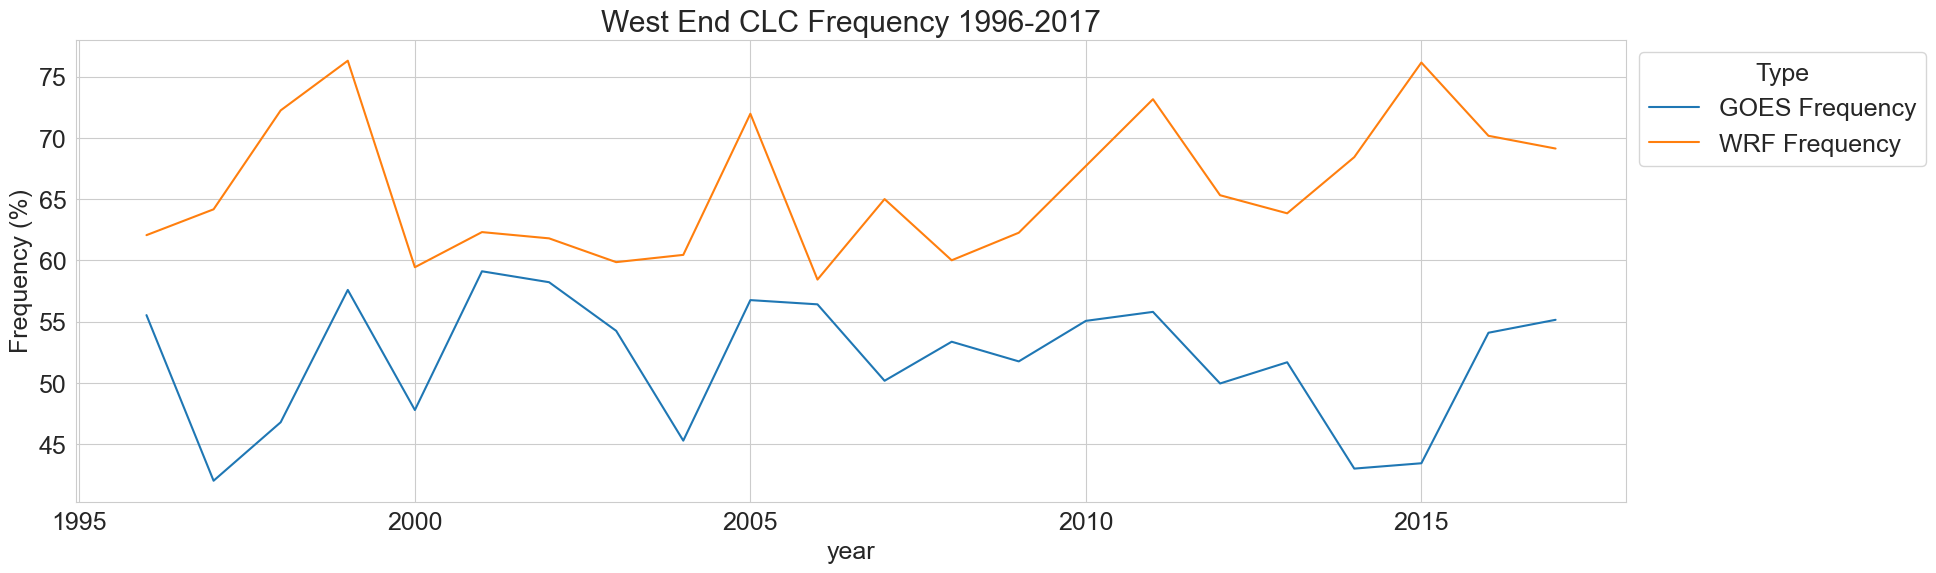

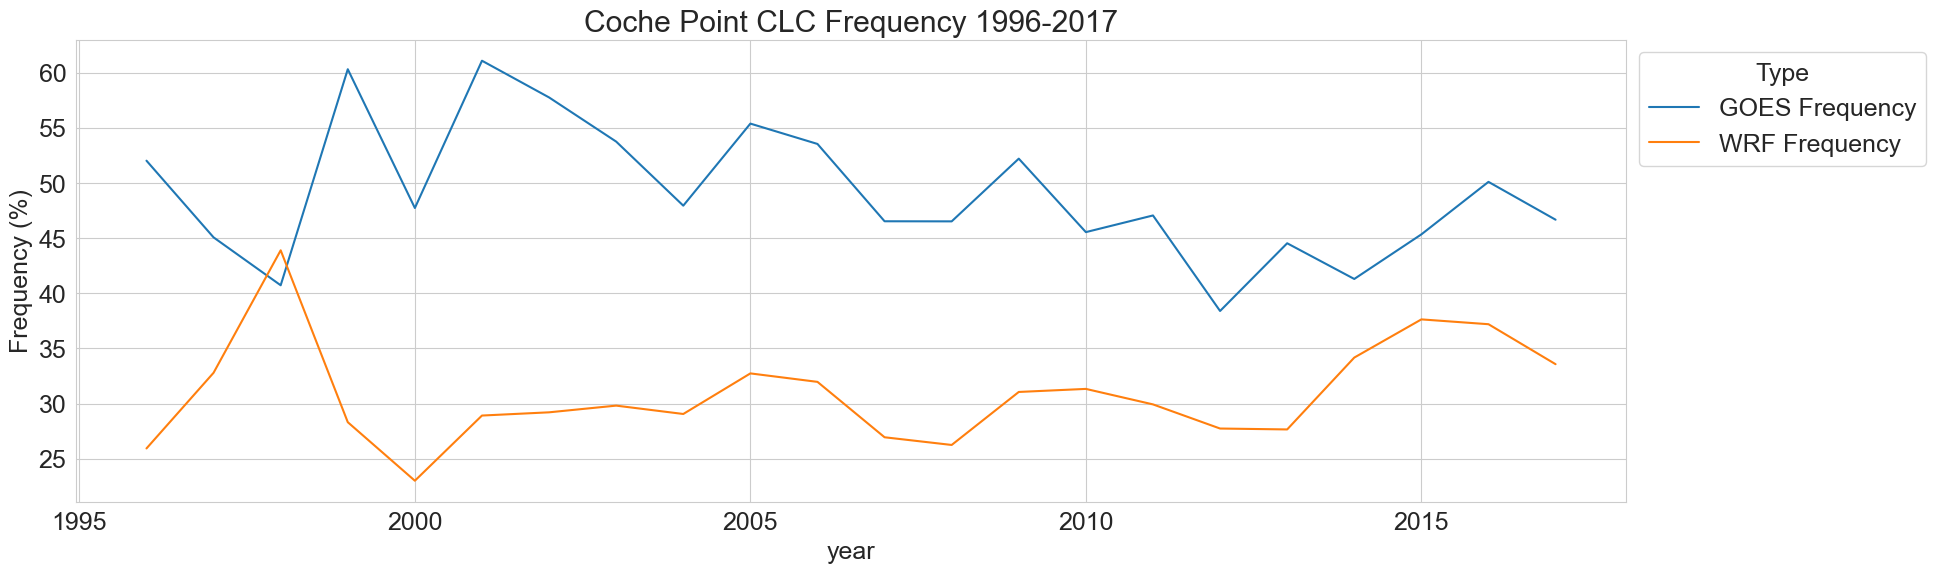

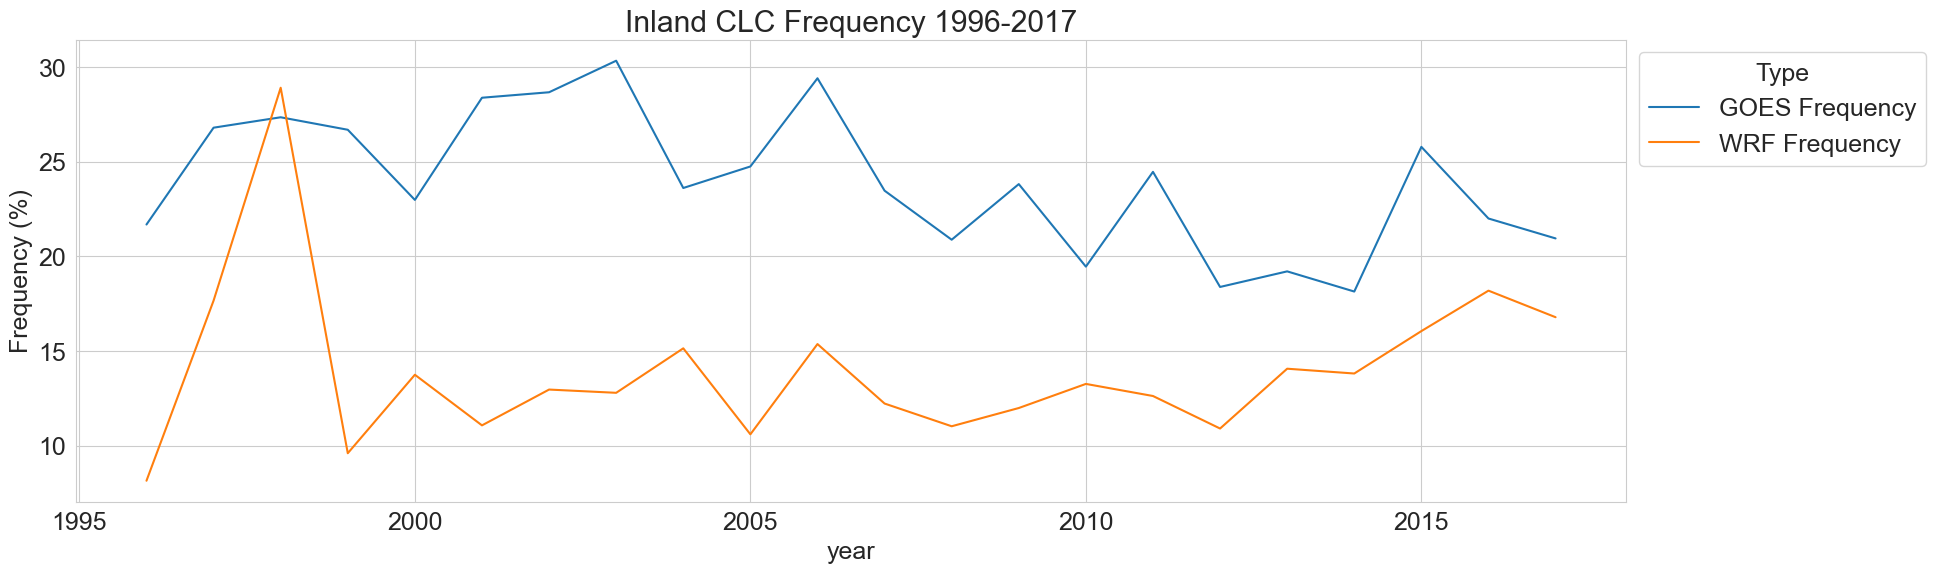

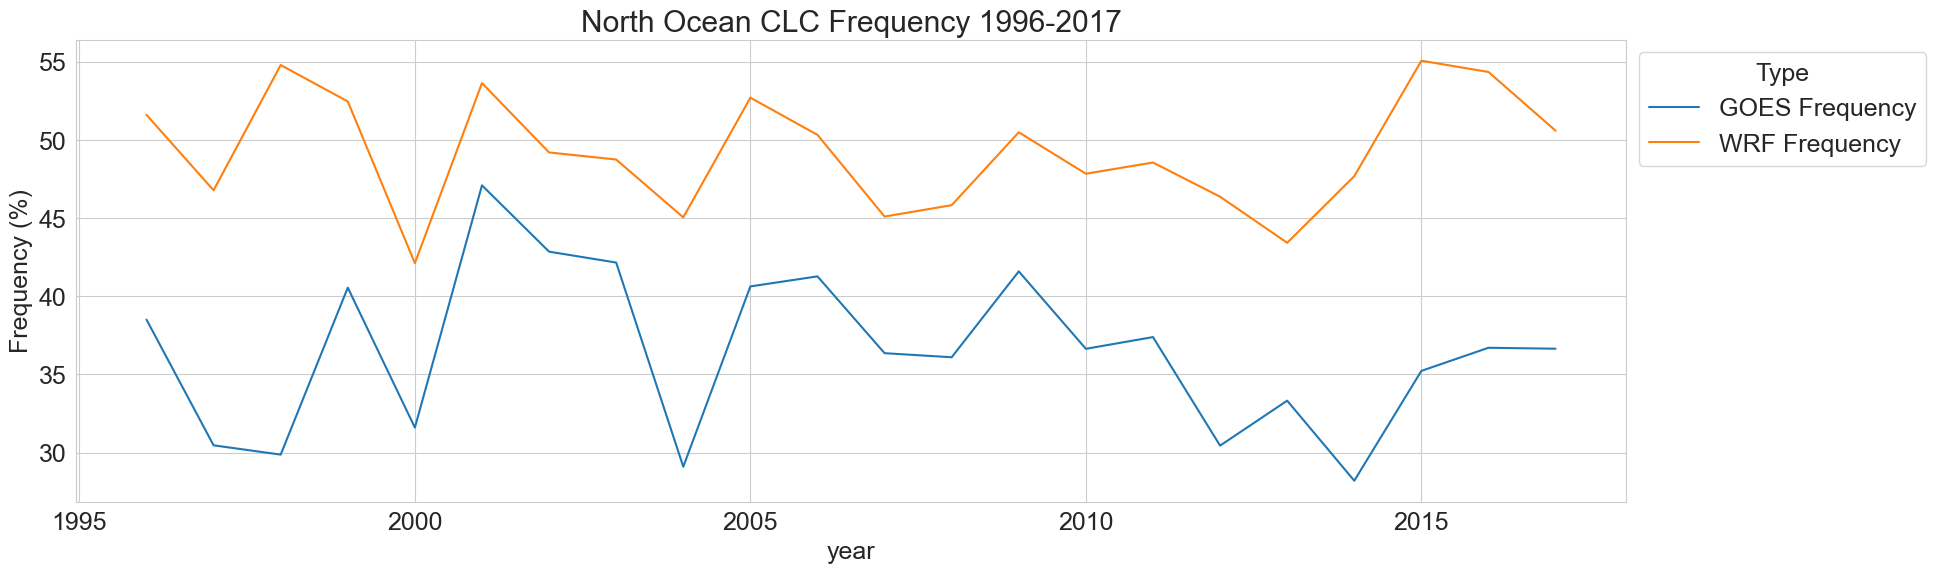

In [92]:
# Get yearly frequencies
freq_df = get_yearly_freq(ds, roi_df)

# Plot ROI mean frequencies by year
for site in freq_df['site'].unique().tolist():
    site_freq_df = freq_df.loc[freq_df['site'] == site].drop('site', axis=1)
    site_freq_df_long = site_freq_df.melt(id_vars='year', var_name='type', value_name='frequency')

    fig, ax = plt.subplots(figsize=(20, 6))
    sns.lineplot(data=site_freq_df_long.loc[site_freq_df_long['type'] != 'match_freq'],
                x='year',
                y='frequency',
                hue='type',
                hue_order=['goes_freq', 'wrf_freq'],
                ax=ax)

    # Customize legend labels
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ["GOES Frequency", "WRF Frequency"]
    ax.legend(handles, custom_labels, title="Type", loc='upper left', 
            bbox_to_anchor=(1, 1))

    site = site.replace("-", " ").title()
    ax.set(title=f'{site} CLC Frequency 1996-2017',
        xlabel='year',
        ylabel='Frequency (%)')

    plt.show()

## Scatter Plots

### CLC Frequency vs. Match Percent

Correlation between GOES CLC Frequency and WRF CLC Frequency: -0.795


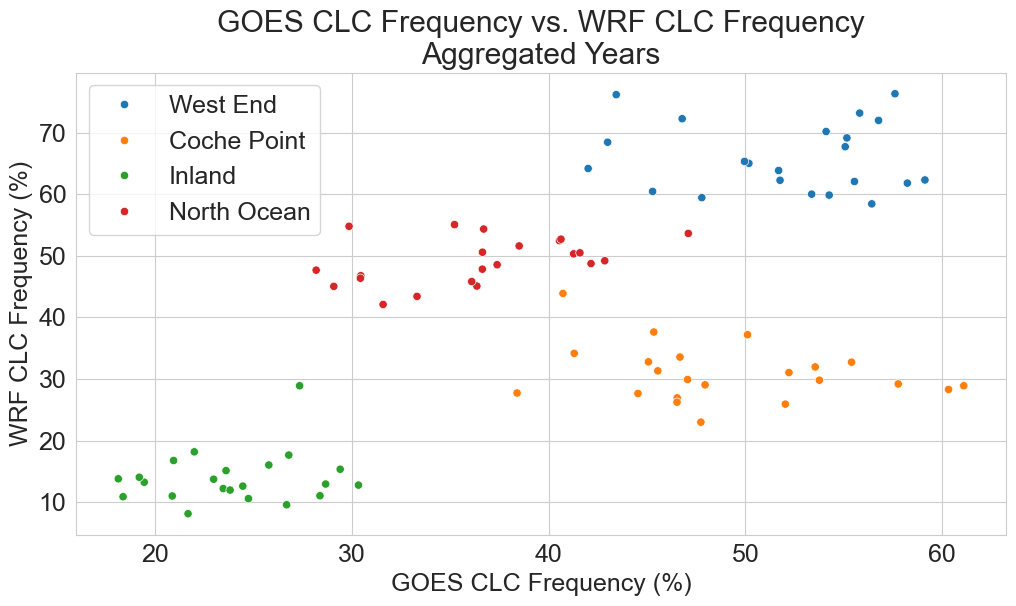

In [94]:
# Get yearly frequencies
freq_df = get_yearly_freq(ds, roi_df)

# Scatter plot WRF vs. GOES CLC Frequencies by Year
corr = np.corrcoef(freq_df['goes_freq'], freq_df['match_freq'])[0, 1]
print(f'Correlation between GOES CLC Frequency and WRF CLC Frequency: {round(corr, 3)}')

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=freq_df,
                x='goes_freq',
                y='wrf_freq',
                hue='site')
ax.set(title='GOES CLC Frequency vs. WRF CLC Frequency\nAggregated Years',
       xlabel='GOES CLC Frequency (%)',
       ylabel='WRF CLC Frequency (%)')

# Modify legend labels
labels = freq_df['site'].unique()
formatted_labels = [label.replace('-', ' ').title() for label in labels]
# Customize legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, formatted_labels, title='')
plt.show()


Correlation between GOES CLC Frequency and Match Frequency: -0.795


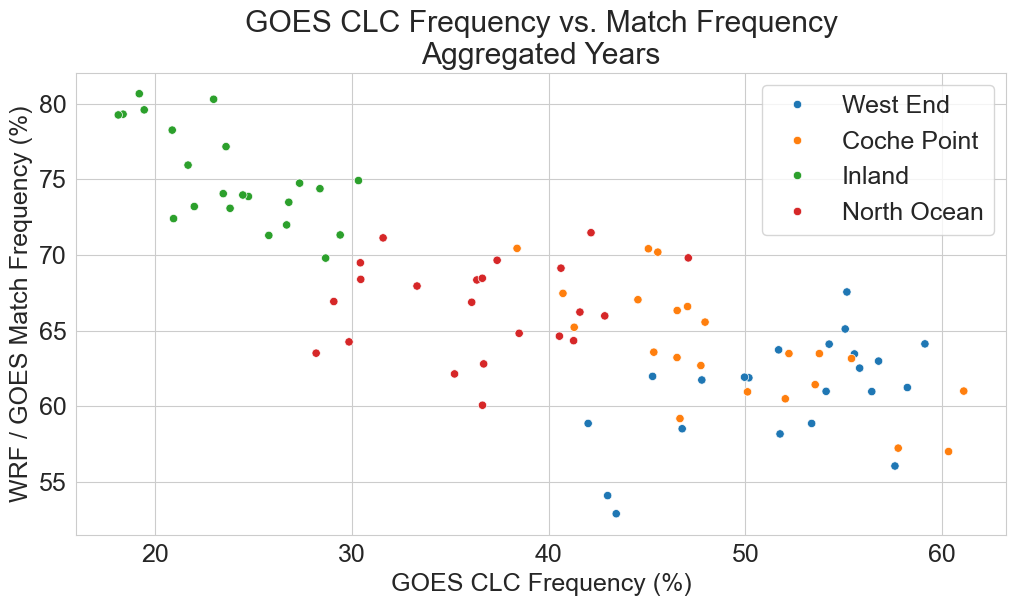

In [95]:
# Scatter plot of Match % vs. GOES frequency
corr = np.corrcoef(freq_df['goes_freq'], freq_df['match_freq'])[0, 1]
print(f'Correlation between GOES CLC Frequency and Match Frequency: {round(corr, 3)}')
fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data=freq_df,
                x='goes_freq',
                y='match_freq',
                hue='site')
ax.set(title='GOES CLC Frequency vs. Match Frequency\nAggregated Years',
       xlabel='GOES CLC Frequency (%)',
       ylabel='WRF / GOES Match Frequency (%)')

# Modify legend labels
labels = freq_df['site'].unique()
formatted_labels = [label.replace('-', ' ').title() for label in labels]
# Customize legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, formatted_labels, title='')
plt.show()


### CLC Frequency vs. WRF Frequency - Monthly Scatterplot

In [96]:
# Aggregate by year/month
month_ds = ds.groupby(['time.year', 'time.month']).sum()
total_counts = ds.groupby(['time.year', 'time.month']).count()
month_ds = month_ds / total_counts * 100  # Get cloudy % per month
freq_df = pd.DataFrame()

for name in site_df['site'].tolist():
    # Subset to specific region of interest
    site_coords = site_df.loc[site_df['site'] == name]
    roi_ds = month_ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))

    # Average over the ROI
    roi_df_mean = roi_ds.mean(dim=['lat', 'lon']).to_dataframe().reset_index()

    roi_df_mean['site'] = name

    # Join together with all sites
    freq_df = pd.concat([freq_df, roi_df_mean])
    
freq_df = freq_df.reset_index(drop=True)
freq_df = freq_df[['site', 'year', 'month', 'alb_binary', 'wrf_binary']].rename({'alb_binary' : 'goes_freq', 'wrf_binary' : 'wrf_freq'}, axis=1)

In [ ]:
# Compute correlation stratified by 'category'
correlations = freq_df.groupby("site").apply(lambda g: g["goes_freq"].corr(g["wrf_freq"]))
print(correlations)

site
coche-point    0.413367
inland         0.616012
north-ocean    0.547032
west-end       0.393190
dtype: float64


/var/folders/77/txzkwfd92_q42s0qflv4nbh00000gn/T/ipykernel_30776/953839185.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = freq_df.groupby("site").apply(lambda g: g["goes_freq"].corr(g["wrf_freq"]))


Correlation: 0.586


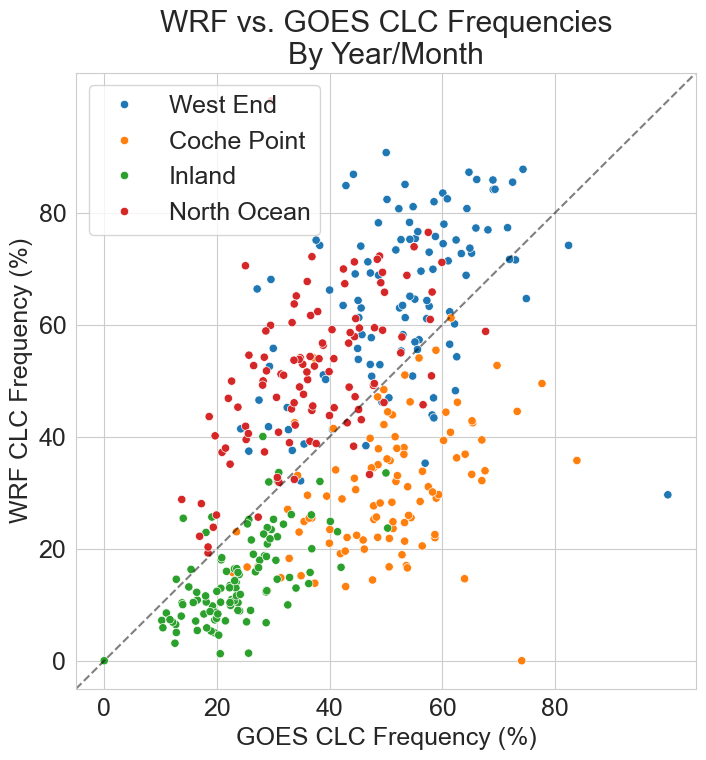

In [102]:
corr = freq_df['goes_freq'].corr(freq_df['wrf_freq'])
print(f'Correlation: {round(corr, 3)}')

# Scatterplot of WRF vs. Goes Frequencies by year/month
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(data=freq_df,
                x='goes_freq',
                y='wrf_freq',
                hue='site')
ax.set(title='WRF vs. GOES CLC Frequencies\nBy Year/Month',
       xlabel='GOES CLC Frequency (%)',
       ylabel='WRF CLC Frequency (%)')
ax.legend(title='')
ticks = list(range(0,100,20))
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Add diagonal line
ax.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.5, transform=ax.transAxes)

# Modify legend labels
labels = freq_df['site'].unique()
formatted_labels = [label.replace('-', ' ').title() for label in labels]
# Customize legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, formatted_labels, title='')
plt.show()

/var/folders/77/txzkwfd92_q42s0qflv4nbh00000gn/T/ipykernel_30776/1257831847.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['West End', 'Coche Point', 'Inland', 'North Ocean'])


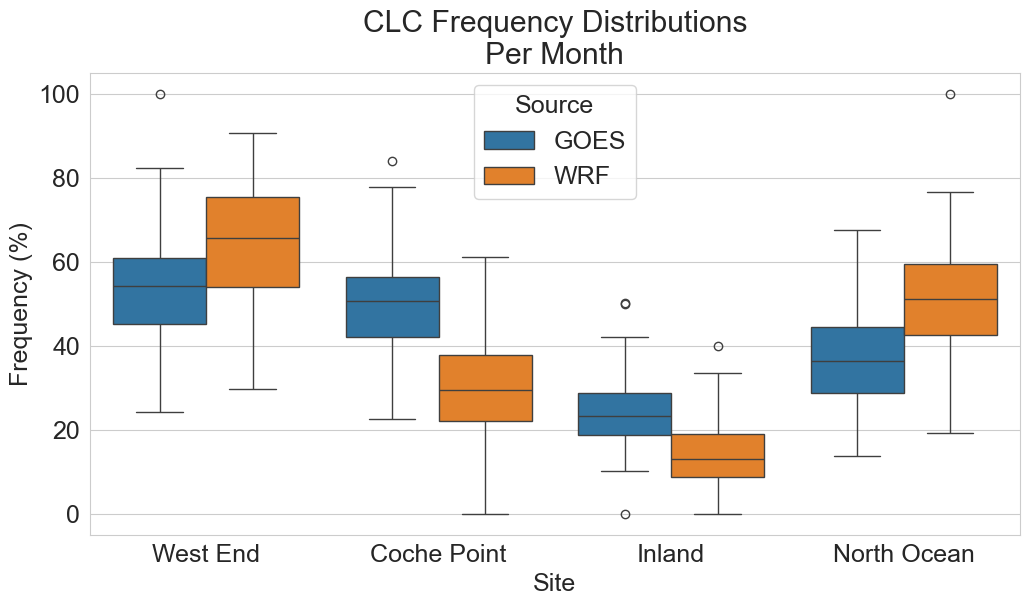

In [103]:
# Boxplot distributions of CLC frequency, stratified by GOES/WRF
freq_df_long = freq_df.melt(id_vars=['site', 'year', 'month'], value_name='freq', var_name='type')
fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(data=freq_df_long,
            x='site',
            y='freq',
            hue='type',
            ax=ax)
ax.set(title='CLC Frequency Distributions\nPer Month',
       xlabel='Site',
       ylabel='Frequency (%)')
ax.set_xticklabels(['West End', 'Coche Point', 'Inland', 'North Ocean'])
# Get the current legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Ensure correct ordering by assigning the new labels
plt.legend(handles, ["GOES", "WRF"], title="Source")
plt.show()

# Standardized Comparisons

### Trend Comparison

In [104]:
# Group to month/year observations
ds_gp = ds.groupby(['time.year', 'time.month']).sum(dim='time')
total_count = ds.groupby(['time.year', 'time.month']).count(dim='time')
ds_gp = ds_gp / total_count * 100

# Average over entire study area
ds_gp = ds_gp.groupby(['year', 'month']).mean(dim=['lat', 'lon'])
df_gp = ds_gp[['alb_binary', 'wrf_binary']].to_dataframe().reset_index()
df_gp = df_gp.rename({'alb_binary': 'goes-freq', 'wrf_binary' : 'wrf-freq'}, axis=1)

print(df_gp.isna().sum())  # Very few na values
df_gp.dropna(inplace=True)

year         0
month        0
goes-freq    4
wrf-freq     4
dtype: int64


In [108]:
# Standardize the data
scaler = StandardScaler()
df_gp['goes-std'] = scaler.fit_transform(df_gp[['goes-freq']])
df_gp['wrf-std'] = scaler.fit_transform(df_gp[['wrf-freq']])

MSE: 0.672


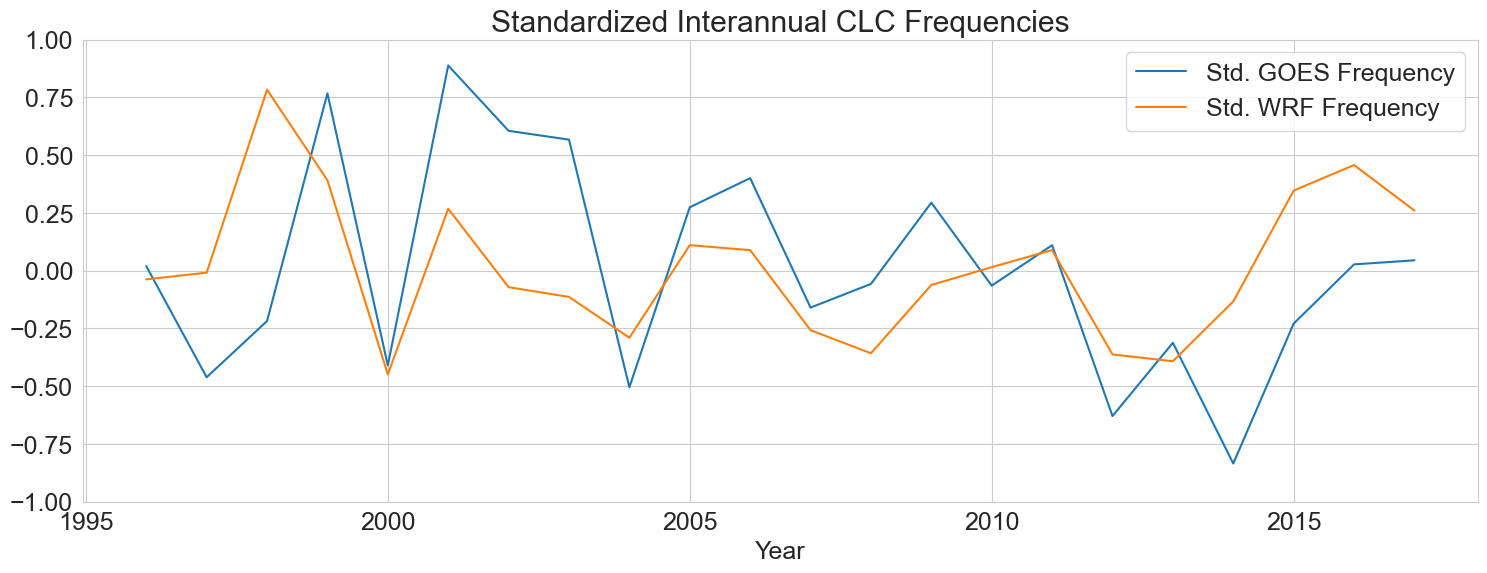

In [110]:
# Calculate similarities
mse = mean_squared_error(df_gp['goes-std'], df_gp['wrf-std'])
print("MSE:", round(mse,3))

# Plot the data
fig, ax = plt.subplots(figsize=(18,6))
sns.lineplot(data=df_gp,
             x='year',
             y='goes-std',
             label='Std. GOES Frequency',
             errorbar=None)
sns.lineplot(data=df_gp,
             x='year',
             y='wrf-std',
             label='Std. WRF Frequency',
             errorbar=None)
ax.set(title='Standardized Interannual CLC Frequencies',
       xlabel='Year',
       ylabel='')
ax.set_ylim(-1,1)
plt.show()

west-end 0.39


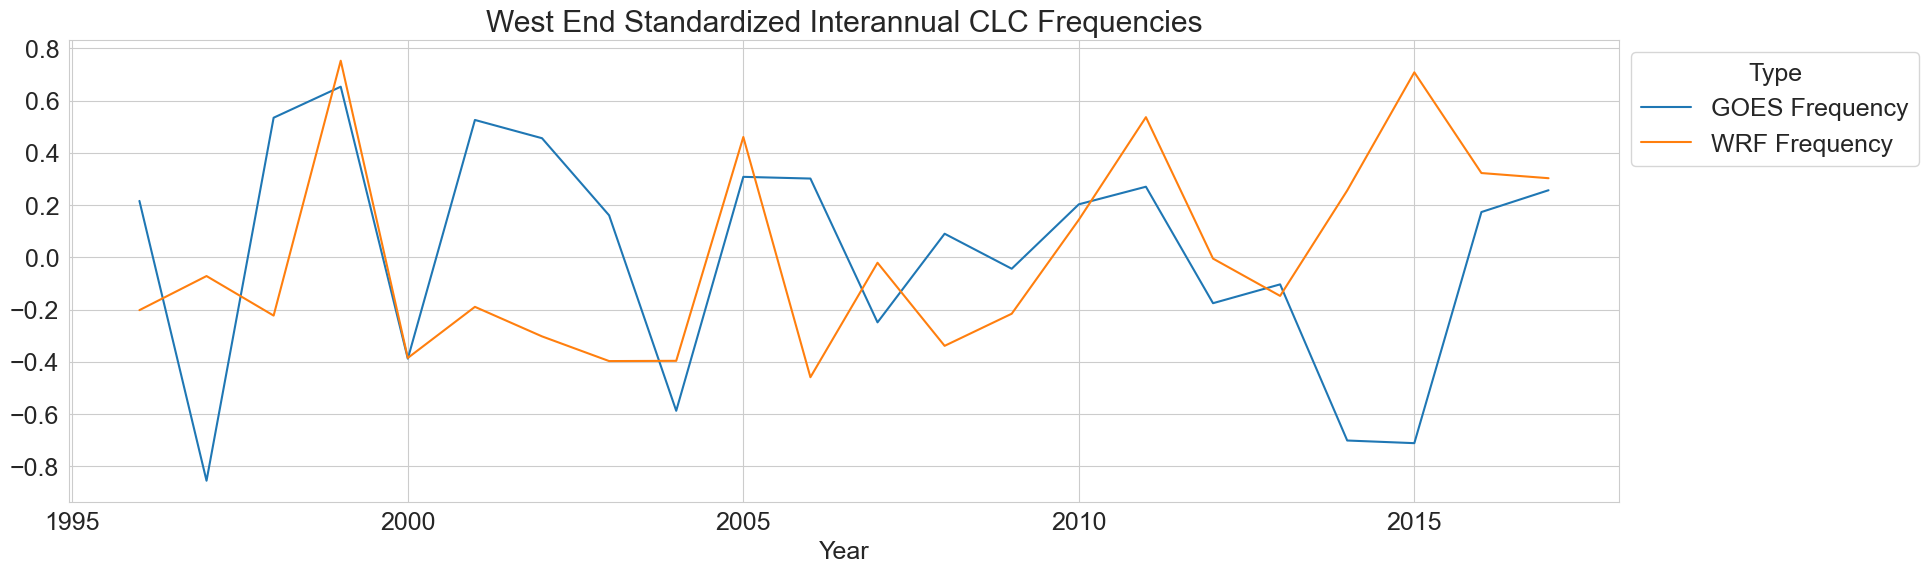

coche-point 0.41


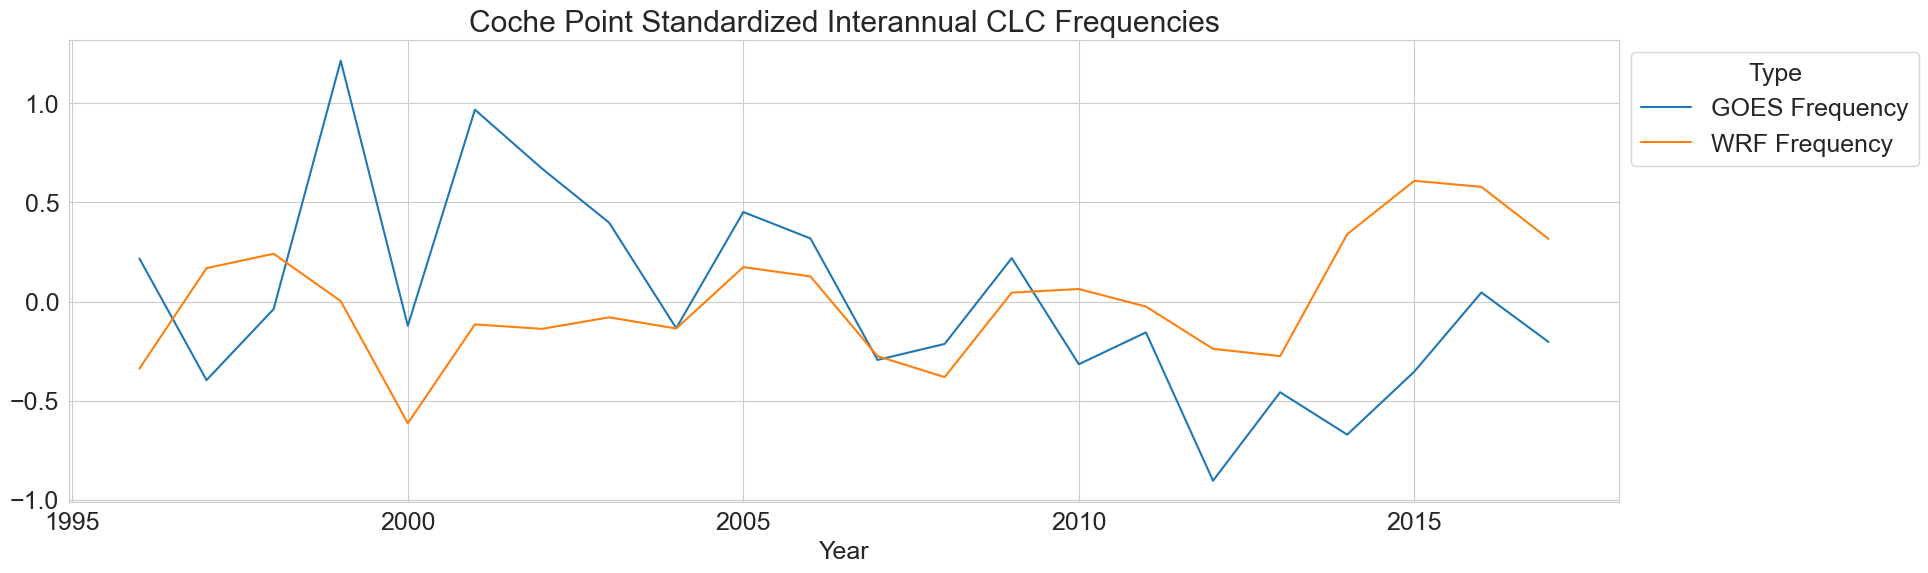

inland 0.62


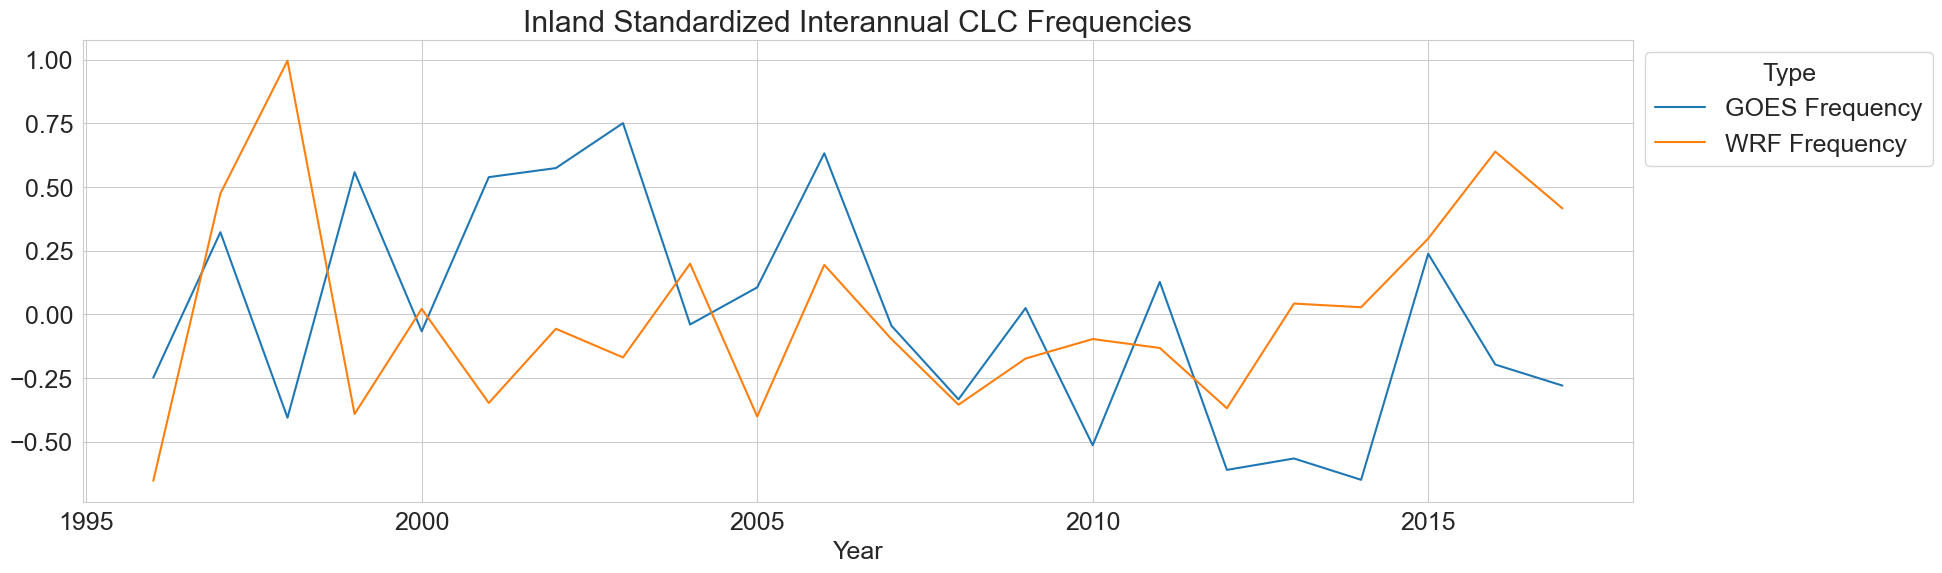

north-ocean 0.55


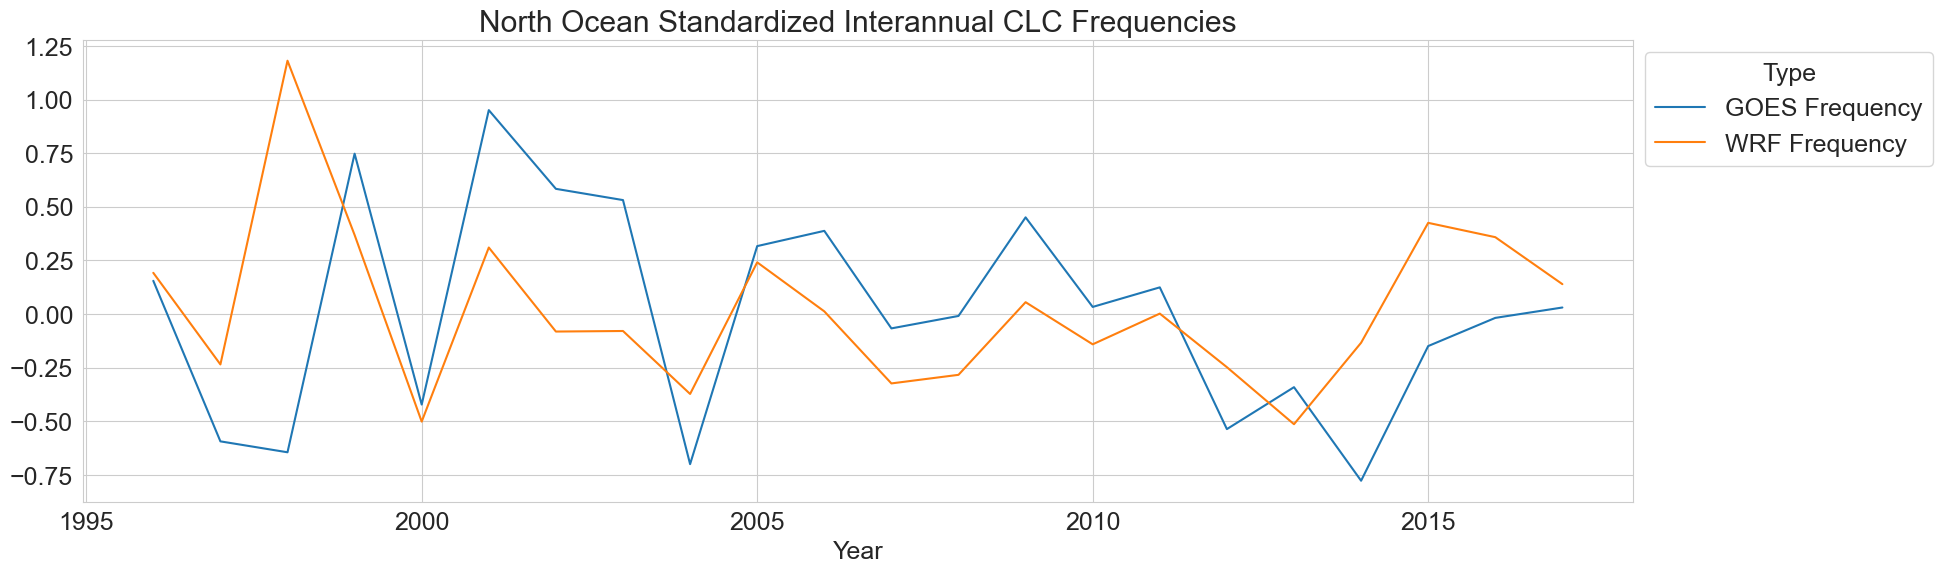

In [111]:
for site in list(freq_df['site'].unique()):
    site_freq_df = freq_df.loc[freq_df['site'] == site].drop('site', axis=1)

    scaler = StandardScaler()
    site_freq_df['goes-std'] = scaler.fit_transform(site_freq_df[['goes_freq']])
    site_freq_df['wrf-std'] = scaler.fit_transform(site_freq_df[['wrf_freq']])
    corr = site_freq_df['goes_freq'].corr(site_freq_df['wrf_freq'])
    print(f'{site} {round(corr, 2)}')

    site_freq_df_long = site_freq_df.melt(id_vars='year', var_name='type', value_name='frequency')

    fig, ax = plt.subplots(figsize=(20, 6))
    sns.lineplot(data=site_freq_df_long.loc[site_freq_df_long['type'] != 'match_freq'],
                x='year',
                y='frequency',
                hue='type',
                hue_order=['goes-std', 'wrf-std'],
                errorbar=None,
                ax=ax)

    # Customize legend labels
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ["GOES Frequency", "WRF Frequency"]
    ax.legend(handles, custom_labels, title="Type", loc='upper left', 
            bbox_to_anchor=(1, 1))

    site = site.replace("-", " ").title()
    ax.set(title=f'{site} Standardized Interannual CLC Frequencies',
        xlabel='Year',
        ylabel='')

    plt.show()